In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

DRIVE_DIR    = "/content/drive/MyDrive/humanoid_3d_project"
DRIVE_FRAMES = os.path.join(DRIVE_DIR, "frames")
DRIVE_OUTPUT = os.path.join(DRIVE_DIR, "output")
DRIVE_VIDEO  = os.path.join(DRIVE_DIR, "video")
DRIVE_CKPTS  = os.path.join(DRIVE_DIR, "checkpoints")

for d in [DRIVE_FRAMES, DRIVE_OUTPUT, DRIVE_VIDEO, DRIVE_CKPTS]:
    os.makedirs(d, exist_ok=True)

print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


In [2]:
# ==========================================
# 1. MOUNT DRIVE & SET PATHS
# ==========================================
from google.colab import drive
import os
import sys

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/humanoid_3d_project'

# Clone if missing
if not os.path.exists(project_path):
    !git clone https://github.com/Rheacoutinho/humanoid-perception-3d-reconstruction {project_path}
else:
    print("✅ Project folder already exists in Drive! Skipping clone.")

# Link to Python environment
if project_path not in sys.path:
    sys.path.append(project_path)
    # If your files are tucked inside a 'src' folder, link that too:
    sys.path.append(os.path.join(project_path, 'src'))

print("🔗 Environment linked successfully.")

# ==========================================
# 2. IMPORT REPO FILES (Adjust names to match your repo)
# ==========================================
# Replace these with the actual filenames inside your GitHub repo
try:
    # Example if you have a file named 'utils.py' or 'models.py'
    # import utils
    # import models
    print("📦 Custom GitHub modules imported successfully!")
except ImportError as e:
    print(f"⚠️ Could not import a module: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Project folder already exists in Drive! Skipping clone.
🔗 Environment linked successfully.
📦 Custom GitHub modules imported successfully!


In [3]:
import os, sys

REPO_DIR = "/content/humanoid-perception-3d-reconstruction"

# Clone/update repo
if not os.path.exists(REPO_DIR):
    os.system(f"git clone https://github.com/Rheacoutinho/humanoid-perception-3d-reconstruction.git {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull origin main -q")

sys.path.insert(0, os.path.join(REPO_DIR, "src"))

# Core packages
os.system("pip install open3d transformers gradio scipy tqdm plotly anthropic -q")

# FastSAM — lightweight CPU-friendly segmentor
if not os.path.exists("/content/FastSAM"):
    os.system("git clone https://github.com/CASIA-IVA-Lab/FastSAM.git /content/FastSAM -q")
    os.system("pip install -r /content/FastSAM/requirements.txt -q")
sys.path.insert(0, "/content/FastSAM")

# CLIP
os.system("pip install git+https://github.com/openai/CLIP.git -q")

import torch
print(f"✓ Environment ready")
print(f"  CUDA : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
torch.cuda.empty_cache() if torch.cuda.is_available() else None

✓ Environment ready
  CUDA : False


In [4]:
FASTSAM_CKPT = os.path.join(DRIVE_CKPTS, "FastSAM-s.pt")

if not os.path.exists(FASTSAM_CKPT):
    print("Downloading FastSAM-s (~23MB)...")
    os.system(
        f"wget -q --show-progress "
        f"https://huggingface.co/spaces/An-619/FastSAM/resolve/main/weights/FastSAM-s.pt "
        f"-O {FASTSAM_CKPT}"
    )
    print("✓ FastSAM checkpoint saved")
else:
    print(f"✓ FastSAM exists ({os.path.getsize(FASTSAM_CKPT)/1e6:.1f} MB)")

✓ FastSAM exists (23.9 MB)


In [8]:
import os
os.environ["GROQ_API_KEY"] = "gsk_your_key_here"

os.environ["HF_API_TOKEN"] = "hf_your_key_here"

# Depth Estimator

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

# ── All persistent paths on Drive ────────────────────────────────────────────
DRIVE_DIR    = "/content/drive/MyDrive/humanoid_3d_project"
DRIVE_FRAMES = os.path.join(DRIVE_DIR, "frames")
DRIVE_OUTPUT = os.path.join(DRIVE_DIR, "output")
DRIVE_VIDEO  = os.path.join(DRIVE_DIR, "video")
DRIVE_CKPTS  = os.path.join(DRIVE_DIR, "checkpoints")

for d in [DRIVE_FRAMES, DRIVE_OUTPUT, DRIVE_VIDEO, DRIVE_CKPTS]:
    os.makedirs(d, exist_ok=True)

# ── API keys — paste yours here ───────────────────────────────────────────────
os.environ["GROQ_API_KEY"] = "gsk_your_key_here"
os.environ["HF_API_TOKEN"] = "hf_your_token_here"

# ── Clone or update repo ──────────────────────────────────────────────────────
REPO_DIR = "/content/humanoid-perception-3d-reconstruction

print("✓ Drive mounted")
print(f"  Project: {DRIVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive mounted
  Project: /content/drive/MyDrive/humanoid_3d_project


In [7]:
import os, sys

REPO_DIR = "/content/humanoid-perception-3d-reconstruction"

# Clone or update repo
if not os.path.exists(REPO_DIR):
    os.system(
        f"git clone https://github.com/Rheacoutinho/"
        f"humanoid-perception-3d-reconstruction.git {REPO_DIR}"
    )
    print("✓ Repo cloned")
else:
    os.system(f"cd {REPO_DIR} && git pull origin main -q")
    print("✓ Repo updated")

# Add src and root to path
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

# Install packages
print("Installing packages (2-3 min first time)...")
os.system("pip install open3d transformers>=4.45.0 "
          "gradio plotly groq ultralytics scipy tqdm -q")
os.system("pip install git+https://github.com/openai/CLIP.git -q")
print("✓ Packages installed")

# Verify GPU
import torch
print(f"\nCUDA  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    torch.cuda.empty_cache()

✓ Repo updated
Installing packages (2-3 min first time)...
✓ Packages installed

CUDA  : False


In [8]:
from google.colab import files
import re, os

DRIVE_VIDEO = "/content/drive/MyDrive/humanoid_3d_project/video"

existing = [f for f in os.listdir(DRIVE_VIDEO)
            if f.lower().endswith((".mp4", ".mov", ".avi"))]

if existing:
    VIDEO_PATH = os.path.join(DRIVE_VIDEO, existing[0])
    print(f"✓ Video found: {existing[0]}")
    print(f"  Size: {os.path.getsize(VIDEO_PATH)/1e6:.1f} MB")
else:
    print("No video found — uploading now...")
    uploaded = files.upload()
    for name, data in uploaded.items():
        clean = re.sub(r"[^\w\-.]", "_", name)
        clean = re.sub(r"_+", "_", clean)
        VIDEO_PATH = os.path.join(DRIVE_VIDEO, clean)
        with open(VIDEO_PATH, "wb") as f:
            f.write(data)
        print(f"✓ Saved: {VIDEO_PATH} "
              f"({os.path.getsize(VIDEO_PATH)/1e6:.1f} MB)")

✓ Video found: hall.mp4
  Size: 4.2 MB


In [9]:
import json, cv2, numpy as np, os

METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")

def extract_frames(video_path, output_dir, num_frames=80,
                   max_side=518, sharpness_threshold=30.0, min_frames=40):
    os.makedirs(output_dir, exist_ok=True)
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    dur   = total / fps

    print(f"Video : {os.path.basename(video_path)}")
    print(f"  {dur:.1f}s · {fps:.0f}fps · {total} frames")

    indices = np.linspace(0, total-1, min(num_frames, total),
                          dtype=int).tolist()
    indices = list(dict.fromkeys(indices))

    candidates = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret or frame is None:
            continue
        grey  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        score = float(cv2.Laplacian(grey, cv2.CV_64F).var())
        candidates.append((idx, score, frame))
    cap.release()

    threshold = sharpness_threshold
    while True:
        kept = [(i,s,f) for i,s,f in candidates if s >= threshold]
        if len(kept) >= min_frames or threshold <= 5.0:
            break
        threshold *= 0.75
    if len(kept) < min_frames:
        kept = candidates

    print(f"  Kept {len(kept)} frames (threshold={threshold:.1f})")

    frame_files = []
    sharpness   = {}
    for i, (_, score, bgr) in enumerate(kept):
        h, w  = bgr.shape[:2]
        scale = max_side / max(h, w)
        if scale < 1.0:
            bgr = cv2.resize(bgr,
                             (int(w*scale), int(h*scale)),
                             interpolation=cv2.INTER_AREA)
        fname = f"frame_{i:04d}.png"
        cv2.imwrite(os.path.join(output_dir, fname), bgr)
        frame_files.append(fname)
        sharpness[fname] = round(score, 2)

    metadata = {
        "video_path" : video_path,
        "fps"        : round(fps, 3),
        "duration_s" : round(dur, 2),
        "frames_kept": len(frame_files),
        "max_side_px": max_side,
        "frame_files": frame_files,
        "sharpness"  : sharpness,
    }
    with open(os.path.join(output_dir, "frames_metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2)

    scores = list(sharpness.values())
    print(f"  Sharpness: min={min(scores):.0f} "
          f"max={max(scores):.0f} mean={np.mean(scores):.0f}")
    print(f"✓ Frames saved to {output_dir}")
    return metadata

if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH) as f:
        meta = json.load(f)
    print(f"✓ Frames already on Drive: {meta['frames_kept']} frames")
else:
    meta = extract_frames(
        video_path=VIDEO_PATH,
        output_dir=DRIVE_FRAMES,
        num_frames=80,
        max_side=518,
        sharpness_threshold=30.0,
        min_frames=40,
    )

✓ Frames already on Drive: 78 frames


Test- Depth estimator

In [10]:
import sys, os
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction")
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction/src")

from depth_estimator import DepthEstimator, compute_global_scale
import json, cv2, numpy as np, matplotlib.pyplot as plt

METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")
DEPTHS_DIR    = os.path.join(DRIVE_OUTPUT, "depths")

with open(METADATA_PATH) as f:
    meta = json.load(f)

frame_files = meta["frame_files"]
frame_paths = [os.path.join(DRIVE_FRAMES, f) for f in frame_files]

# Load estimator
estimator = DepthEstimator()  # auto-detects GPU/CPU

Loading Depth-Anything V2 Small on cpu...
  Model : depth-anything/Depth-Anything-V2-Small-hf
  (~80MB download on first run, then cached)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✓ Depth estimator ready


In [11]:
# This runs depth estimation on all frames
# Skips any frame that already has a saved depth map
# So if Colab crashes mid-way, just re-run — it picks up where it left off

depth_stats = estimator.estimate_batch(
    frame_paths = frame_paths,
    output_dir  = DEPTHS_DIR,
    show_progress = True,
)

# Compute global scale factor
from config import NEAR_ANCHOR_M
GLOBAL_SCALE = compute_global_scale(depth_stats, near_anchor_m=NEAR_ANCHOR_M)

print(f"\n✓ Depth estimation complete")
print(f"  Frames processed : {len(depth_stats)}")
print(f"  Global scale     : {GLOBAL_SCALE:.4f}")
print(f"  Depths saved to  : {DEPTHS_DIR}")


✓ Depth estimation complete: 78 frames
Global depth scale:
  Median near depth (normalised, 5th pct) : 0.0725
  Assumed near distance                   : 0.5m
  Scale factor                            : 6.8919
  Expected max depth                      : ~6.89m

✓ Depth estimation complete
  Frames processed : 78
  Global scale     : 6.8919
  Depths saved to  : /content/drive/MyDrive/humanoid_3d_project/output/depths


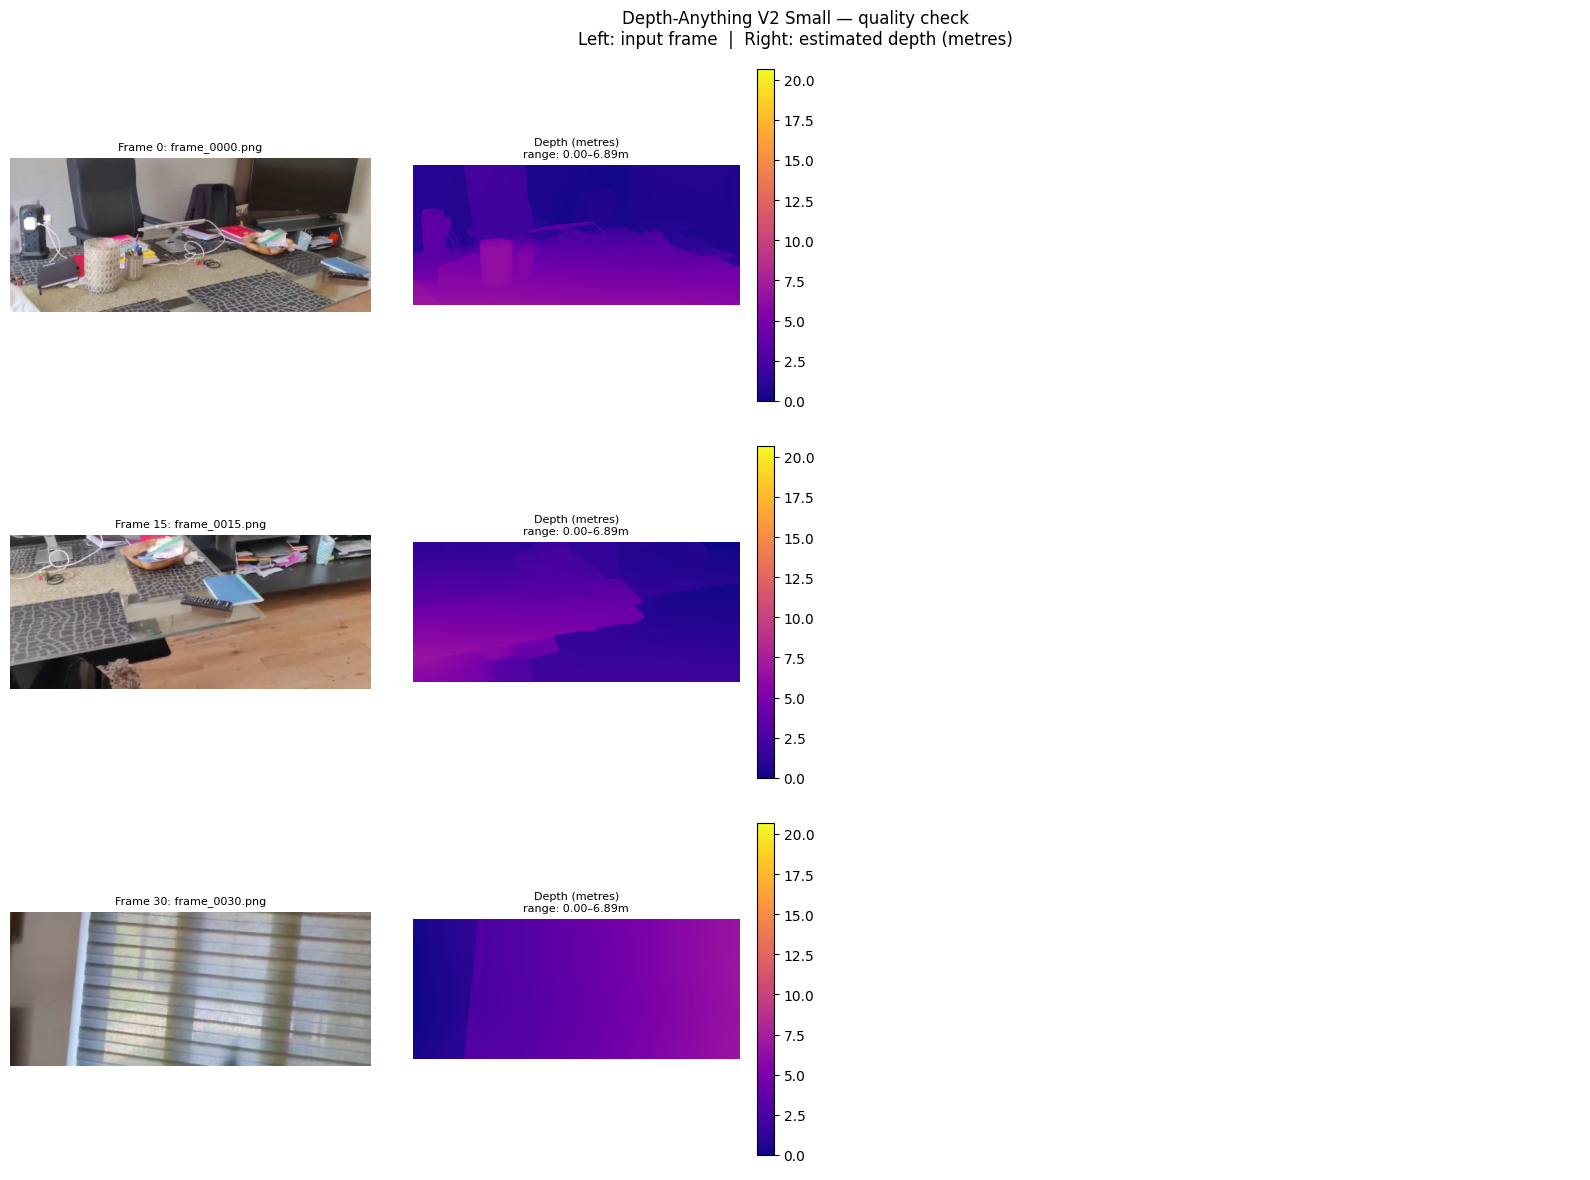

✓ Saved to Drive: /content/drive/MyDrive/humanoid_3d_project/output/depth_quality_check.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cv2, os

# Show 6 frames with their depth maps side by side
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

sample_indices = np.linspace(0, len(frame_files)-1, 6, dtype=int)

for row, idx in enumerate(sample_indices[:3]):
    fname  = frame_files[idx]
    dpath  = depth_stats[fname]["path"]

    img    = cv2.imread(os.path.join(DRIVE_FRAMES, fname))
    img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    depth  = np.load(dpath)
    depth_m = depth * GLOBAL_SCALE  # convert to metres

    col = (row % 3) * 2

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Frame {idx}: {fname}", fontsize=8)
    axes[row, 0].axis("off")

    im = axes[row, 1].imshow(depth_m, cmap="plasma",
                              vmin=0, vmax=GLOBAL_SCALE * 3)
    axes[row, 1].set_title(
        f"Depth (metres)\n"
        f"range: {depth_m.min():.2f}–{depth_m.max():.2f}m",
        fontsize=8
    )
    axes[row, 1].axis("off")
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046)

# Hide unused axes
for i in range(3):
    axes[i, 2].axis("off")
    axes[i, 3].axis("off")

plt.suptitle("Depth-Anything V2 Small — quality check\n"
             "Left: input frame  |  Right: estimated depth (metres)",
             fontsize=12)
plt.tight_layout()
save_path = os.path.join(DRIVE_OUTPUT, "depth_quality_check.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved to Drive: {save_path}")

In [13]:
import os

depths_dir = DEPTHS_DIR
depth_files = [f for f in os.listdir(depths_dir) if f.endswith(".npy")]

print("=== File 1 Verification ===")
print(f"  Frames in metadata : {len(frame_files)}")
print(f"  Depth files saved  : {len(depth_files)}")
print(f"  Global scale       : {GLOBAL_SCALE:.4f}")
print(f"  Depths directory   : {depths_dir}")

# Quick sanity: load first and last depth and check shape
d0 = np.load(os.path.join(depths_dir, "depth_0000.npy"))
print(f"\n  depth_0000.npy shape : {d0.shape}")
print(f"  depth_0000.npy range : {d0.min():.4f} – {d0.max():.4f}")

sample_img = cv2.imread(os.path.join(DRIVE_FRAMES, frame_files[0]))
print(f"  frame_0000.png shape : {sample_img.shape[:2]}")
print(f"  Shapes match         : {d0.shape == sample_img.shape[:2]}")

all_good = (
    len(depth_files) == len(frame_files) and
    d0.shape == sample_img.shape[:2]
)

print(f"\n{'✓ File 1 PASSED — ready for File 2' if all_good else '✗ Something wrong — check errors above'}")

=== File 1 Verification ===
  Frames in metadata : 78
  Depth files saved  : 78
  Global scale       : 6.8919
  Depths directory   : /content/drive/MyDrive/humanoid_3d_project/output/depths

  depth_0000.npy shape : (222, 518)
  depth_0000.npy range : 0.0000 – 1.0000
  frame_0000.png shape : (222, 518)
  Shapes match         : True

✓ File 1 PASSED — ready for File 2


# Pose Estimator

In [14]:
import os
os.system("cd /content/humanoid-perception-3d-reconstruction && git pull origin main -q")
print("✓ Repo updated")

✓ Repo updated


Debug

In [ ]:
import cv2, numpy as np, os, json, sys
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction")
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction/src")

METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")
DEPTHS_DIR    = os.path.join(DRIVE_OUTPUT, "depths")

with open(METADATA_PATH) as f:
    meta = json.load(f)

frame_files = meta["frame_files"]
frame_paths = [os.path.join(DRIVE_FRAMES, f) for f in frame_files]

# Load frames 0 and 1
img0 = cv2.imread(frame_paths[0])
img1 = cv2.imread(frame_paths[1])
H, W = img0.shape[:2]

# Load depth maps 0 and 1
d0 = np.load(os.path.join(DEPTHS_DIR, "depth_0000.npy"))
d1 = np.load(os.path.join(DEPTHS_DIR, "depth_0001.npy"))

print("=== Image diagnostics ===")
print(f"  Frame 0 shape  : {img0.shape}  (H={H}, W={W})")
print(f"  Depth 0 shape  : {d0.shape}")
print(f"  Depth 0 range  : {d0.min():.4f} – {d0.max():.4f}")
print(f"  Depth 0 dtype  : {d0.dtype}")
print(f"  Depth 0 >1.0   : {(d0 > 1.0).sum()} pixels")
print(f"  Depth 0 >0.05  : {(d0 > 0.05).sum()} pixels")

# Normalise and scale
d0_norm  = d0 / 255.0 if d0.max() > 1.0 else d0
d0_metric = d0_norm * GLOBAL_SCALE

print(f"\n=== Metric depth (after scale={GLOBAL_SCALE:.4f}) ===")
print(f"  Min  : {d0_metric.min():.4f}m")
print(f"  Max  : {d0_metric.max():.4f}m")
print(f"  Mean : {d0_metric.mean():.4f}m")
print(f"  In range [0.1, 6.0]m : "
      f"{((d0_metric >= 0.1) & (d0_metric <= 6.0)).sum()} pixels")

# Test ORB matching between frame 0 and 1
orb = cv2.ORB_create(nfeatures=3000)
bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

grey0 = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)
grey1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

kps0, des0 = orb.detectAndCompute(grey0, None)
kps1, des1 = orb.detectAndCompute(grey1, None)

print(f"\n=== ORB matching diagnostics ===")
print(f"  Keypoints frame 0 : {len(kps0)}")
print(f"  Keypoints frame 1 : {len(kps1)}")

if des0 is not None and des1 is not None:
    matches = bf.match(des0, des1)
    matches = sorted(matches, key=lambda x: x.distance)
    print(f"  Matches found     : {len(matches)}")
    print(f"  Best match dist   : {matches[0].distance:.1f}")
    print(f"  Median match dist : {np.median([m.distance for m in matches]):.1f}")

    # Test back-projection for first 5 matches
    print(f"\n=== Back-projection test (first 5 matches) ===")
    focal = W / 1.4
    cx, cy = W / 2.0, H / 2.0
    print(f"  focal={focal:.1f}  cx={cx:.1f}  cy={cy:.1f}")

    for j, m in enumerate(matches[:5]):
        u, v = kps0[m.queryIdx].pt
        u_i  = int(round(u))
        v_i  = int(round(v))
        u_i  = np.clip(u_i, 0, W-1)
        v_i  = np.clip(v_i, 0, H-1)

        raw   = float(d0[v_i, u_i])
        norm  = raw / 255.0 if raw > 1.0 else raw
        metric = norm * GLOBAL_SCALE

        x_cam = (u_i - cx) / focal * metric
        y_cam = (v_i - cy) / focal * metric
        z_cam = metric

        valid = (metric >= 0.1) and (metric <= 6.0)
        print(f"  Match {j}: px=({u_i},{v_i})  "
              f"raw={raw:.1f}  metric={metric:.3f}m  "
              f"3D=({x_cam:.3f},{y_cam:.3f},{z_cam:.3f})  "
              f"valid={'YES' if valid else 'NO'}")
else:
    print("  ERROR: No descriptors found in one or both frames")

=== Image diagnostics ===
  Frame 0 shape  : (222, 518, 3)  (H=222, W=518)
  Depth 0 shape  : (222, 518)
  Depth 0 range  : 0.0000 – 1.0000
  Depth 0 dtype  : float32
  Depth 0 >1.0   : 0 pixels
  Depth 0 >0.05  : 110063 pixels

=== Metric depth (after scale=6.8919) ===
  Min  : 0.0000m
  Max  : 6.8919m
  Mean : 2.7491m
  In range [0.1, 6.0]m : 105465 pixels

=== ORB matching diagnostics ===
  Keypoints frame 0 : 2030
  Keypoints frame 1 : 2151
  Matches found     : 1016
  Best match dist   : 9.0
  Median match dist : 34.0

=== Back-projection test (first 5 matches) ===
  focal=370.0  cx=259.0  cy=111.0
  Match 0: px=(455,114)  raw=0.1  metric=0.649m  3D=(0.344,0.005,0.649)  valid=YES
  Match 1: px=(251,140)  raw=0.5  metric=3.568m  3D=(-0.077,0.280,3.568)  valid=YES
  Match 2: px=(58,149)  raw=0.5  metric=3.324m  3D=(-1.806,0.341,3.324)  valid=YES
  Match 3: px=(422,105)  raw=0.1  metric=0.703m  3D=(0.310,-0.011,0.703)  valid=YES
  Match 4: px=(251,142)  raw=0.5  metric=3.649m  3D=(-0

Fix

In [15]:
import os, sys

# Pull fixes
os.system("cd /content/humanoid-perception-3d-reconstruction && git pull origin main -q")

# Clear cached modules so fixes are loaded
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['depth_estimator', 'pose_estimator', 'config']):
        del sys.modules[mod]

sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction")
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction/src")

from depth_estimator import (
    DepthEstimator,
    compute_global_scale,
    renormalise_existing_depths,
)

DEPTHS_DIR    = os.path.join(DRIVE_OUTPUT, "depths")
METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")

# Step 1 — Fix the already-saved depth files
print("Step 1: Renormalising existing depth files...")
renormalise_existing_depths(DEPTHS_DIR)

# Step 2 — Recompute global scale on normalised depths
print("\nStep 2: Recomputing global scale...")
import json, numpy as np

with open(METADATA_PATH) as f:
    meta = json.load(f)

frame_files = meta["frame_files"]

# Rebuild depth_stats pointing to the now-normalised files
depth_stats = {}
for i, fname in enumerate(frame_files):
    dpath = os.path.join(DEPTHS_DIR, f"depth_{i:04d}.npy")
    d     = np.load(dpath)
    depth_stats[fname] = {
        "min"  : float(d.min()),
        "max"  : float(d.max()),
        "mean" : float(d.mean()),
        "path" : dpath,
    }

from config import NEAR_ANCHOR_M
GLOBAL_SCALE = compute_global_scale(depth_stats, near_anchor_m=NEAR_ANCHOR_M)

print(f"\n✓ New global scale : {GLOBAL_SCALE:.4f}")
print(f"  Expected max depth: ~{1.0 * GLOBAL_SCALE:.2f}m")
print(f"  (Should be 3–8m for a typical indoor room)")

Step 1: Renormalising existing depth files...
✓ Renormalised 0/78 depth files in /content/drive/MyDrive/humanoid_3d_project/output/depths

Step 2: Recomputing global scale...
Global depth scale:
  Median near depth (normalised, 5th pct) : 0.0725
  Assumed near distance                   : 0.5m
  Scale factor                            : 6.8919
  Expected max depth                      : ~6.89m

✓ New global scale : 6.8919
  Expected max depth: ~6.89m
  (Should be 3–8m for a typical indoor room)


In [16]:
import numpy as np, os

# Check one depth file
d0     = np.load(os.path.join(DEPTHS_DIR, "depth_0000.npy"))
d0_m   = d0 * GLOBAL_SCALE

print("Depth sanity check after fix:")
print(f"  Raw range    : {d0.min():.4f} – {d0.max():.4f}  "
      f"(should be 0–1)")
print(f"  Metric range : {d0_m.min():.3f}m – {d0_m.max():.3f}m  "
      f"(should be 0–8m)")
print(f"  Valid pixels : "
      f"{((d0_m >= 0.1) & (d0_m <= 6.0)).sum():,}  "
      f"(should be >50,000)")

ok = d0.max() <= 1.01 and d0_m.max() > 1.0
print(f"\n{'✓ Depths look correct' if ok else '✗ Still wrong — paste output'}")

Depth sanity check after fix:
  Raw range    : 0.0000 – 1.0000  (should be 0–1)
  Metric range : 0.000m – 6.892m  (should be 0–8m)
  Valid pixels : 105,465  (should be >50,000)

✓ Depths look correct


In [17]:
import cv2, json, os
from pose_estimator import PoseEstimator

POSES_PATH  = os.path.join(DRIVE_OUTPUT, "poses.json")
frame_paths = [os.path.join(DRIVE_FRAMES, f) for f in frame_files]

sample = cv2.imread(frame_paths[0])
H, W   = sample.shape[:2]

print(f"Image size   : {W} × {H}")
print(f"Global scale : {GLOBAL_SCALE:.4f}")
print(f"Expected max : {GLOBAL_SCALE:.2f}m\n")

estimator_pose = PoseEstimator(image_w=W, image_h=H)

poses_data = estimator_pose.estimate_poses(
    frame_paths  = frame_paths,
    depths_dir   = DEPTHS_DIR,
    global_scale = GLOBAL_SCALE,
)

estimator_pose.save_poses(poses_data, POSES_PATH)

Image size   : 518 × 222
Global scale : 6.8919
Expected max : 6.89m

PoseEstimator initialised
  Image size   : 518 × 222
  Focal length : 370.0 px
  cx, cy       : (259.0, 111.0)
Estimating poses for 78 frames...
  Extracting ORB keypoints...
    Frame   1/78 — 2030 keypoints
    Frame  20/78 — 1353 keypoints
    Frame  40/78 — 176 keypoints
    Frame  60/78 — 678 keypoints

  Estimating poses via depth-anchored PnP...
    Frame   2/78 — PnP success: 1/2 recent  | best inliers: 546
    Frame  20/78 — PnP success: 19/20 recent  | best inliers: 407
    Frame  40/78 — PnP success: 20/20 recent  | best inliers: 76
    Frame  60/78 — PnP success: 20/20 recent  | best inliers: 49

  Pose estimation complete:
    PnP success  : 77/78  (98.7%)
    Fallback     : 0
    Avg inliers  : 225.9
    (Good = >60% PnP success, >15 avg inliers)
✓ Poses saved: /content/drive/MyDrive/humanoid_3d_project/output/poses.json
  (78 frames, 98.7% PnP success)


In [18]:
import json, numpy as np

with open(POSES_PATH) as f:
    pd = json.load(f)

positions = np.array([
    np.array(p["cam_to_world"])[:3, 3]
    for p in pd["poses"]
])

x_r = positions[:,0].max() - positions[:,0].min()
y_r = positions[:,1].max() - positions[:,1].min()
z_r = positions[:,2].max() - positions[:,2].min()

print("=== File 2 Re-verification ===")
print(f"  PnP success : {pd['pnp_success_pct']}%")
print(f"  Avg inliers : {pd['avg_inliers']}")
print(f"  X range     : {x_r:.2f}m")
print(f"  Y range     : {y_r:.2f}m")
print(f"  Z range     : {z_r:.2f}m")

ok = (pd['pnp_success_pct'] >= 40 and x_r < 15 and y_r < 8 and z_r < 15)
print(f"\n{'✓ File 2 PASSED — ready for File 3' if ok else '⚠ Paste output here'}")

=== File 2 Re-verification ===
  PnP success : 98.7%
  Avg inliers : 225.9
  X range     : 1.09m
  Y range     : 1.47m
  Z range     : 0.93m

✓ File 2 PASSED — ready for File 3


# Cloud Builder

In [19]:
os.system("cd /content/humanoid-perception-3d-reconstruction && git pull origin main -q")
for mod in list(sys.modules.keys()):
    if 'cloud_builder' in mod:
        del sys.modules[mod]
print("✓ Updated")

✓ Updated


In [20]:
import sys, os, json
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction")
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction/src")

from cloud_builder import CloudBuilder

POSES_PATH    = os.path.join(DRIVE_OUTPUT, "poses.json")
DEPTHS_DIR    = os.path.join(DRIVE_OUTPUT, "depths")
METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")

with open(POSES_PATH) as f:
    poses_data = json.load(f)

with open(METADATA_PATH) as f:
    meta = json.load(f)

frame_files = meta["frame_files"]
frame_paths = [os.path.join(DRIVE_FRAMES, f) for f in frame_files]

builder = CloudBuilder(poses_data)

pcd = builder.build_rgb_cloud(
    frame_paths = frame_paths,
    depths_dir  = DEPTHS_DIR,
    output_dir  = DRIVE_OUTPUT,
    batch_size  = 10,
)

print(f"\n✓ Point cloud built: {len(pcd.points):,} points")

CloudBuilder initialised
  Frames    : 78
  Image     : 518 × 222
  Scale     : 6.8919
  Depth rng : 0.1m – 6.0m
Back-projecting 78 frames (batch size=10)...
  Batch 1/8 — frames 1–10 → 521,437 pts after downsample
  Batch 2/8 — frames 11–20 → 495,833 pts after downsample
  Batch 3/8 — frames 21–30 → 769,063 pts after downsample
  Batch 4/8 — frames 31–40 → 818,132 pts after downsample
  Batch 5/8 — frames 41–50 → 923,381 pts after downsample
  Batch 6/8 — frames 51–60 → 638,132 pts after downsample
  Batch 7/8 — frames 61–70 → 799,665 pts after downsample
  Batch 8/8 — frames 71–78 → 693,906 pts after downsample

Merging all batches...
  Total raw points : 8,416,286
  After batched DS : 5,659,549
  After final DS   : 5,243,399
  After outlier rm : 5,104,685

✓ RGB cloud saved : /content/drive/MyDrive/humanoid_3d_project/output/pointcloud_rgb.ply  (137.8 MB)

✓ Point cloud built: 5,104,685 points


Points : 5,104,685
X      : -3.745 → 5.522  (9.267m)
Y      : -6.021 → 8.675  (14.696m)
Z      : -7.164 → 7.780  (14.944m)


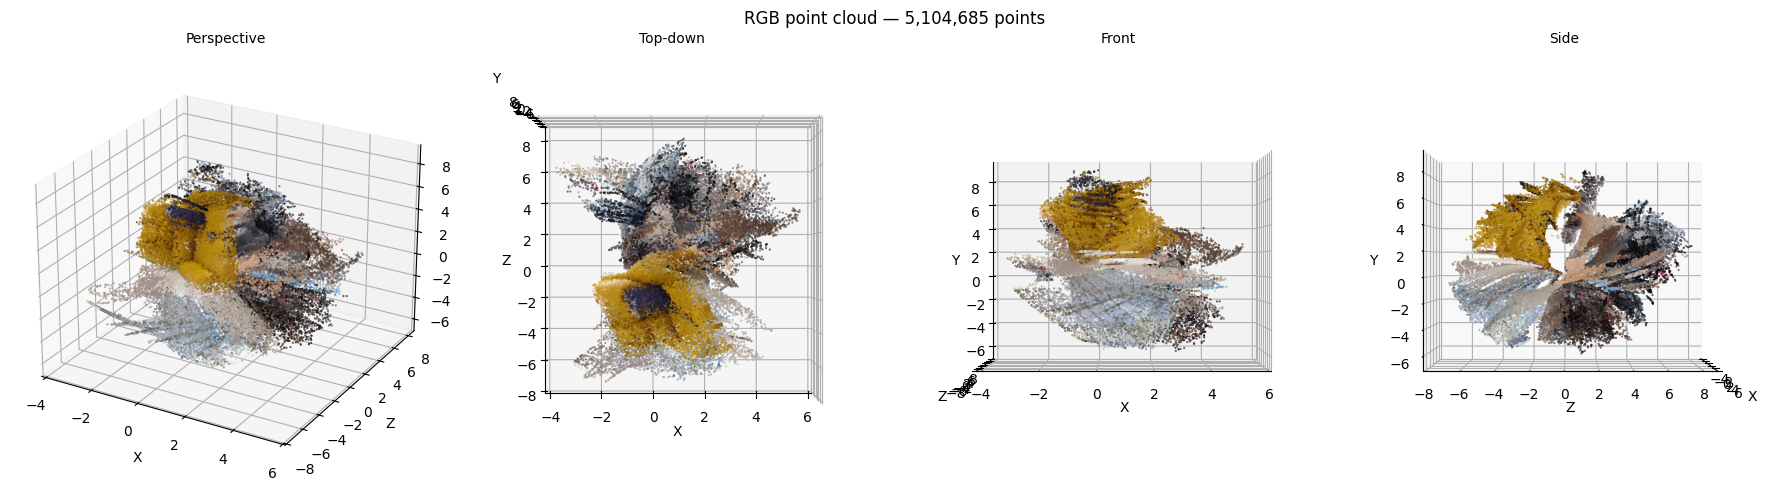

✓ Saved: /content/drive/MyDrive/humanoid_3d_project/output/cloud_check.png


In [21]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import os

ply_path = os.path.join(DRIVE_OUTPUT, "pointcloud_rgb.ply")
pcd      = o3d.io.read_point_cloud(ply_path)
pts      = np.asarray(pcd.points)
cols     = np.asarray(pcd.colors)

print(f"Points : {len(pts):,}")
print(f"X      : {pts[:,0].min():.3f} → {pts[:,0].max():.3f}  "
      f"({pts[:,0].max()-pts[:,0].min():.3f}m)")
print(f"Y      : {pts[:,1].min():.3f} → {pts[:,1].max():.3f}  "
      f"({pts[:,1].max()-pts[:,1].min():.3f}m)")
print(f"Z      : {pts[:,2].min():.3f} → {pts[:,2].max():.3f}  "
      f"({pts[:,2].max()-pts[:,2].min():.3f}m)")

N   = min(len(pts), 80_000)
idx = np.random.choice(len(pts), N, replace=False)
p, c = pts[idx], cols[idx]

fig = plt.figure(figsize=(18, 5))
for i, (elev, azim, title) in enumerate([
    (25, -60, "Perspective"),
    (90, -90, "Top-down"),
    (0,  -90, "Front"),
    (0,    0, "Side"),
]):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    ax.scatter(p[:,0], p[:,2], p[:,1], c=c, s=0.3, alpha=0.7)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_zlabel("Y")

plt.suptitle(f"RGB point cloud — {len(pts):,} points", fontsize=12)
plt.tight_layout()
save_path = os.path.join(DRIVE_OUTPUT, "cloud_check.png")
plt.savefig(save_path, dpi=150)
plt.show()
print(f"✓ Saved: {save_path}")

In [22]:
import os, numpy as np
import open3d as o3d

ply_path = os.path.join(DRIVE_OUTPUT, "pointcloud_rgb.ply")
pcd      = o3d.io.read_point_cloud(ply_path)
pts      = np.asarray(pcd.points)

has_colour = np.asarray(pcd.colors).mean() > 0.001
has_points = len(pts) > 1000

print("=== File 3 Verification ===")
print(f"  Points     : {len(pts):,}  "
      f"({'OK' if has_points else 'TOO FEW'})")
print(f"  Has colour : {has_colour}")
print(f"  File size  : {os.path.getsize(ply_path)/1e6:.1f} MB")
print(f"  X range    : {pts[:,0].max()-pts[:,0].min():.3f}m")
print(f"  Y range    : {pts[:,1].max()-pts[:,1].min():.3f}m")
print(f"  Z range    : {pts[:,2].max()-pts[:,2].min():.3f}m")

passed = has_points and has_colour
print(f"\n{'✓ File 3 PASSED — ready for File 4' if passed else '✗ Check errors'}")

=== File 3 Verification ===
  Points     : 5,104,685  (OK)
  Has colour : True
  File size  : 137.8 MB
  X range    : 9.267m
  Y range    : 14.696m
  Z range    : 14.944m

✓ File 3 PASSED — ready for File 4


# Segmentor

In [23]:
os.system("cd /content/humanoid-perception-3d-reconstruction "
          "&& git pull origin main -q")
for mod in list(sys.modules.keys()):
    if 'segmentor' in mod:
        del sys.modules[mod]
print("✓ Updated")

✓ Updated


In [24]:
import os

DRIVE_CKPTS  = "/content/drive/MyDrive/humanoid_3d_project/checkpoints"
FASTSAM_CKPT = os.path.join(DRIVE_CKPTS, "FastSAM-s.pt")

if not os.path.exists(FASTSAM_CKPT):
    print("Downloading FastSAM-s (~23MB)...")
    os.system(
        f"wget -q --show-progress "
        f"https://huggingface.co/spaces/An-619/FastSAM/"
        f"resolve/main/weights/FastSAM-s.pt "
        f"-O {FASTSAM_CKPT}"
    )
    print("✓ FastSAM checkpoint saved to Drive")
else:
    print(f"✓ FastSAM exists "
          f"({os.path.getsize(FASTSAM_CKPT)/1e6:.1f} MB)")

✓ FastSAM exists (23.9 MB)


In [25]:
import os

DRIVE_CKPTS  = "/content/drive/MyDrive/humanoid_3d_project/checkpoints"
FASTSAM_CKPT = os.path.join(DRIVE_CKPTS, "FastSAM-s.pt")

# Remove the broken 0-byte file first
if os.path.exists(FASTSAM_CKPT):
    os.remove(FASTSAM_CKPT)
    print("Removed broken file")

# Try three sources in order until one works
sources = [
    # Source 1 — HuggingFace model hub direct
    "https://huggingface.co/CASIA-IVA-Lab/FastSAM-s/resolve/main/weights/FastSAM-s.pt",
    # Source 2 — GitHub release
    "https://github.com/CASIA-IVA-Lab/FastSAM/releases/download/v1.0/FastSAM-s.pt",
    # Source 3 — alternative HF mirror
    "https://huggingface.co/An-619/FastSAM/resolve/main/FastSAM-s.pt",
]

for i, url in enumerate(sources):
    print(f"\nTrying source {i+1}: {url}")
    ret = os.system(f"wget -q --show-progress -O {FASTSAM_CKPT} '{url}'")

    if os.path.exists(FASTSAM_CKPT):
        size_mb = os.path.getsize(FASTSAM_CKPT) / 1e6
        if size_mb > 10:  # FastSAM-s should be ~23MB
            print(f"✓ Downloaded successfully: {size_mb:.1f} MB")
            break
        else:
            print(f"  File too small ({size_mb:.1f} MB) — trying next source")
            os.remove(FASTSAM_CKPT)
    else:
        print(f"  Download failed — trying next source")

# Final check
if os.path.exists(FASTSAM_CKPT):
    size_mb = os.path.getsize(FASTSAM_CKPT) / 1e6
    if size_mb > 10:
        print(f"\n✓ FastSAM checkpoint ready: {size_mb:.1f} MB")
    else:
        print(f"\n✗ All sources failed — trying pip install method...")
        # Last resort — install via ultralytics which auto-downloads
        os.system("pip install ultralytics -q")
        import ultralytics
        from ultralytics import YOLO
        # This triggers automatic download to ultralytics cache
        model = YOLO("FastSAM-s.pt")
        # Copy from ultralytics cache to our Drive location
        import shutil
        cache_path = os.path.expanduser("~/.config/Ultralytics/")
        found = []
        for root, dirs, files in os.walk(cache_path):
            for f in files:
                if "FastSAM" in f:
                    found.append(os.path.join(root, f))
        if found:
            shutil.copy(found[0], FASTSAM_CKPT)
            print(f"✓ Copied from ultralytics cache: "
                  f"{os.path.getsize(FASTSAM_CKPT)/1e6:.1f} MB")
else:
    print("✗ All download attempts failed")

Removed broken file

Trying source 1: https://huggingface.co/CASIA-IVA-Lab/FastSAM-s/resolve/main/weights/FastSAM-s.pt
  File too small (0.0 MB) — trying next source

Trying source 2: https://github.com/CASIA-IVA-Lab/FastSAM/releases/download/v1.0/FastSAM-s.pt
  File too small (0.0 MB) — trying next source

Trying source 3: https://huggingface.co/An-619/FastSAM/resolve/main/FastSAM-s.pt
  File too small (0.0 MB) — trying next source
✗ All download attempts failed


In [26]:
import os, shutil
import sys # Added this import

DRIVE_CKPTS  = "/content/drive/MyDrive/humanoid_3d_project/checkpoints"
FASTSAM_CKPT = os.path.join(DRIVE_CKPTS, "FastSAM-s.pt")

# Clean up any broken files
for path in [FASTSAM_CKPT, "/content/FastSAM-s.pt"]:
    if os.path.exists(path) and os.path.getsize(path) < 1000:
        os.remove(path)

# ── Method: ultralytics auto-download ────────────────────────────────────────
# ultralytics downloads models from its own CDN which is not blocked
print("Installing ultralytics and downloading FastSAM-s via built-in CDN...")
os.system("pip install ultralytics -q")

# --- Start of fix for ImportError ---
# Remove '/content/FastSAM' from sys.path to prevent package shadowing.
# This path was added in a previous cell and is causing conflict with the 'ultralytics' package.
if "/content/FastSAM" in sys.path:
    sys.path.remove("/content/FastSAM")

# Remove any previously loaded 'ultralytics' modules from sys.modules
# to ensure that the correct 'ultralytics' package is loaded after sys.path modification.
for module in list(sys.modules.keys()):
    if module.startswith('ultralytics'):
        del sys.modules[module]
# --- End of fix for ImportError ---

from ultralytics import FastSAM
import torch

# This line triggers the automatic download to /root/.config/Ultralytics/
# or the current working directory
os.chdir("/content")
try:
    model = FastSAM("FastSAM-s.pt")
    print("✓ FastSAM-s downloaded via ultralytics")
except Exception as e:
    print(f"FastSAM class failed: {e}")
    from ultralytics import YOLO
    model = YOLO("FastSAM-s.pt")
    print("✓ FastSAM-s downloaded via YOLO interface")

# Find where ultralytics saved it
search_dirs = [
    "/content",
    "/root/.config/Ultralytics",
    os.path.expanduser("~"),
    "/root",
]

found_path = None
for search_dir in search_dirs:
    if not os.path.exists(search_dir):
        continue
    for root, dirs, files in os.walk(search_dir):
        for f in files:
            if "FastSAM-s" in f and f.endswith(".pt"):
                candidate = os.path.join(root, f)
                size_mb   = os.path.getsize(candidate) / 1e6
                print(f"Found: {candidate} ({size_mb:.1f} MB)")
                if size_mb > 10:
                    found_path = candidate
                    break
        if found_path:
            break
    if found_path:
        break

if found_path:
    shutil.copy(found_path, FASTSAM_CKPT)
    print(f"\n✓ Copied to Drive: {FASTSAM_CKPT}")
    print(f"  Size: {os.path.getsize(FASTSAM_CKPT)/1e6:.1f} MB")
else:
    print("\n✗ Could not find downloaded file — checking current directory...")
    for f in os.listdir("/content"):
        if "FastSAM" in f or "fastsam" in f.lower():
            size_mb = os.path.getsize(f"/content/{f}") / 1e6
            print(f"  /content/{f} — {size_mb:.1f} MB")
            if size_mb > 10:
                shutil.copy(f"/content/{f}", FASTSAM_CKPT)
                print(f"  ✓ Copied to Drive")
                found_path = FASTSAM_CKPT
                break

# Final verification
if os.path.exists(FASTSAM_CKPT):
    size_mb = os.path.getsize(FASTSAM_CKPT) / 1e6
    print(f"\nFinal check: {size_mb:.1f} MB")
    if size_mb > 10:
        print("✓ FastSAM checkpoint ready")
    else:
        print("✗ Still too small")
else:
    print("✗ File not found at Drive path")

Installing ultralytics and downloading FastSAM-s via built-in CDN...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ FastSAM-s downloaded via ultralytics
Found: /content/FastSAM-s.pt (23.9 MB)

✓ Copied to Drive: /content/drive/MyDrive/humanoid_3d_project/checkpoints/FastSAM-s.pt
  Size: 23.9 MB

Final check: 23.9 MB
✓ FastSAM checkpoint ready


In [27]:
import sys, os, cv2, json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction")
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction/src")

from segmentor import Segmentor

METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")
FASTSAM_CKPT  = "/content/drive/MyDrive/humanoid_3d_project/checkpoints/FastSAM-s.pt"

# Check if the FastSAM checkpoint file exists and is not empty
if not os.path.exists(FASTSAM_CKPT) or os.path.getsize(FASTSAM_CKPT) == 0:
    print("ERROR: FastSAM checkpoint file is missing or empty. This caused the EOFError.")
    print(f"Please re-run the 'Download FastSAM checkpoint' cell (cell mkdLT9n_zao2) to ensure the model downloads correctly.")
    # Raise an error to prevent further execution with a bad checkpoint
    raise FileNotFoundError(f"Corrupted or missing FastSAM checkpoint at {FASTSAM_CKPT}")

with open(METADATA_PATH) as f:
    meta = json.load(f)

frame_files = meta["frame_files"]
frame_paths = [os.path.join(DRIVE_FRAMES, f) for f in frame_files]

# Load segmentor
seg = Segmentor(checkpoint_path=FASTSAM_CKPT)

# Test on frame 0
img_bgr  = cv2.imread(frame_paths[0])
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
masks    = seg.segment(img_bgr)

print(f"\nFrame 0 segmentation:")
print(f"  Image size : {img_bgr.shape[:2]}")
print(f"  Masks found: {len(masks)}")
if masks:
    areas = [m.sum() for m in masks]
    print(f"  Area range : {min(areas)} – {max(areas)} px")
    print(f"  Avg area   : {np.mean(areas):.0f} px")

Loading FastSAM from: /content/drive/MyDrive/humanoid_3d_project/checkpoints/FastSAM-s.pt
Device: cpu
✓ Segmentor ready

Frame 0 segmentation:
  Image size : (222, 518)
  Masks found: 36
  Area range : 249 – 18647 px
  Avg area   : 2914 px


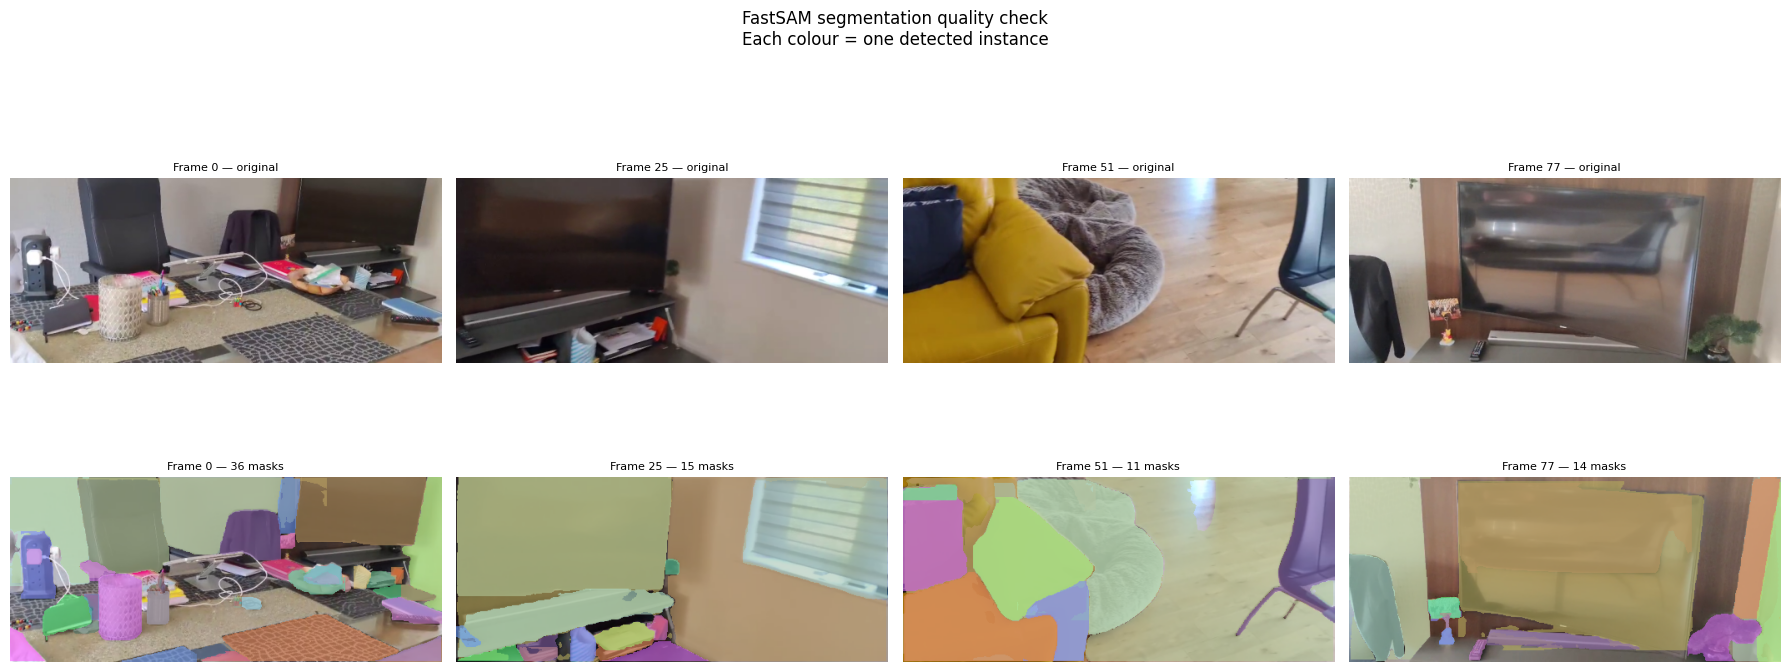

✓ Saved: /content/drive/MyDrive/humanoid_3d_project/output/segmentation_check.png


In [28]:
# Visualise masks on frame 0 and one other frame
MASKS_VIS_DIR = os.path.join(DRIVE_OUTPUT, "mask_vis")
os.makedirs(MASKS_VIS_DIR, exist_ok=True)

def visualise_masks(image_rgb, masks, title=""):
    vis = image_rgb.copy().astype(np.float32)
    np.random.seed(42)
    for mask in masks:
        colour = np.random.randint(80, 255, 3).astype(np.float32)
        for c in range(3):
            vis[:,:,c] = np.where(
                mask, vis[:,:,c]*0.4 + colour[c]*0.6, vis[:,:,c]
            )
    return vis.astype(np.uint8)

# Pick 4 frames spread across the video
test_indices = np.linspace(0, len(frame_paths)-1, 4, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, idx in enumerate(test_indices):
    img   = cv2.cvtColor(cv2.imread(frame_paths[idx]),
                         cv2.COLOR_BGR2RGB)
    msks  = seg.segment(cv2.imread(frame_paths[idx]))
    vis   = visualise_masks(img, msks)

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"Frame {idx} — original", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(vis)
    axes[1, col].set_title(f"Frame {idx} — {len(msks)} masks", fontsize=8)
    axes[1, col].axis("off")

plt.suptitle("FastSAM segmentation quality check\n"
             "Each colour = one detected instance",
             fontsize=12)
plt.tight_layout()
save_path = os.path.join(DRIVE_OUTPUT, "segmentation_check.png")
plt.savefig(save_path, dpi=150)
plt.show()
print(f"✓ Saved: {save_path}")

In [29]:
import json

MASKS_VIS_DIR = os.path.join(DRIVE_OUTPUT, "mask_vis")

all_masks = seg.segment_keyframes(
    frame_paths   = frame_paths,
    keyframe_step = 5,
    save_dir      = MASKS_VIS_DIR,
)

total  = sum(len(v) for v in all_masks.values())
n_keys = len(all_masks)

print("\n=== File 4 Verification ===")
print(f"  Keyframes processed : {n_keys}")
print(f"  Total masks         : {total}")
print(f"  Avg masks/frame     : {total/max(n_keys,1):.1f}")
print(f"  Vis samples saved   : {MASKS_VIS_DIR}")

passed = (n_keys > 0 and total > 0)
print(f"\n{'✓ File 4 PASSED — ready for File 5' if passed else '✗ Check errors'}")

Segmenting 16 keyframes (every 5 frames)...
  Keyframe 1/16 (frame 0): 36 masks
  Keyframe 5/16 (frame 20): 22 masks
  Keyframe 10/16 (frame 45): 21 masks
  Keyframe 15/16 (frame 70): 32 masks

✓ Segmentation complete
  Keyframes processed : 16
  Total masks         : 308
  Avg masks/frame     : 19.2

=== File 4 Verification ===
  Keyframes processed : 16
  Total masks         : 308
  Avg masks/frame     : 19.2
  Vis samples saved   : /content/drive/MyDrive/humanoid_3d_project/output/mask_vis

✓ File 4 PASSED — ready for File 5


# Clip Embedder

In [30]:
os.system("cd /content/humanoid-perception-3d-reconstruction "
          "&& git pull origin main -q")
for mod in list(sys.modules.keys()):
    if 'clip_embedder' in mod:
        del sys.modules[mod]
print("✓ Updated")

✓ Updated


In [31]:
import sys, os
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction")
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction/src")

from clip_embedder import CLIPEmbedder
import numpy as np

embedder = CLIPEmbedder()  # auto-detects GPU/CPU

# Test text embedding
queries = [
    "chair",
    "floor",
    "table",
    "navigable floor space",
    "obstacle blocking path",
]

print("\nText embedding test:")
for q in queries:
    emb = embedder.embed_text(q)
    print(f"  '{q}' → shape={emb.shape}  "
          f"norm={np.linalg.norm(emb):.4f}  "
          f"range=[{emb.min():.3f}, {emb.max():.3f}]")

# Test similarity between related and unrelated queries
emb_chair  = embedder.embed_text("chair")
emb_seat   = embedder.embed_text("seat to sit on")
emb_floor  = embedder.embed_text("floor")

sim_chair_seat  = float(emb_chair @ emb_seat)
sim_chair_floor = float(emb_chair @ emb_floor)

print(f"\nSimilarity sanity check:")
print(f"  'chair' vs 'seat to sit on' : {sim_chair_seat:.3f}  "
      f"(should be HIGH >0.7)")
print(f"  'chair' vs 'floor'          : {sim_chair_floor:.3f}  "
      f"(should be LOWER)")
print(f"  Ordering correct: {sim_chair_seat > sim_chair_floor}")

Loading CLIP ViT-B/32 on cpu...
  (~150MB download on first run, then cached)


100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 96.8MiB/s]


  Pre-computing vocabulary embeddings (49 labels)...
✓ CLIP embedder ready
  Embedding dim : 512
  Vocabulary    : 49 indoor labels

Text embedding test:
  'chair' → shape=(512,)  norm=1.0000  range=[-0.204, 0.530]
  'floor' → shape=(512,)  norm=1.0000  range=[-0.190, 0.539]
  'table' → shape=(512,)  norm=1.0000  range=[-0.220, 0.551]
  'navigable floor space' → shape=(512,)  norm=1.0000  range=[-0.192, 0.567]
  'obstacle blocking path' → shape=(512,)  norm=1.0000  range=[-0.172, 0.547]

Similarity sanity check:
  'chair' vs 'seat to sit on' : 0.908  (should be HIGH >0.7)
  'chair' vs 'floor'          : 0.795  (should be LOWER)
  Ordering correct: True


In [32]:
import cv2, json, numpy as np
import matplotlib.pyplot as plt

METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")

with open(METADATA_PATH) as f:
    meta = json.load(f)

frame_files = meta["frame_files"]
frame_paths = [os.path.join(DRIVE_FRAMES, f) for f in frame_files]

# Load a frame and get its masks
img_bgr = cv2.imread(frame_paths[0])
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Re-use the segmentor from File 4
FASTSAM_CKPT = "/content/drive/MyDrive/humanoid_3d_project/checkpoints/FastSAM-s.pt"
from segmentor import Segmentor
seg   = Segmentor(checkpoint_path=FASTSAM_CKPT)
masks = seg.segment(img_bgr)

print(f"Frame 0: {len(masks)} masks")
print(f"Testing CLIP labelling on each mask...\n")

# Label each mask
labels = embedder.label_all_masks(img_rgb, masks)

# Show results
for i, (mask, label) in enumerate(zip(masks[:8], labels[:8])):
    area_pct = mask.sum() / (mask.shape[0] * mask.shape[1]) * 100
    print(f"  Mask {i:2d}: area={area_pct:.1f}%  "
          f"label='{label['label']}'  "
          f"conf={label['confidence']:.3f}  "
          f"top3={[(l,f'{s:.2f}') for l,s in label['top3']]}")

Loading FastSAM from: /content/drive/MyDrive/humanoid_3d_project/checkpoints/FastSAM-s.pt
Device: cpu
✓ Segmentor ready
Frame 0: 36 masks
Testing CLIP labelling on each mask...

  Mask  0: area=16.2%  label='pillow'  conf=0.277  top3=[('pillow', '0.28'), ('laptop', '0.27'), ('monitor', '0.27')]
  Mask  1: area=10.4%  label='desk'  conf=0.261  top3=[('desk', '0.26'), ('monitor', '0.26'), ('laptop', '0.26')]
  Mask  2: area=9.7%  label='monitor'  conf=0.299  top3=[('monitor', '0.30'), ('laptop', '0.28'), ('chair', '0.28')]
  Mask  3: area=8.2%  label='monitor'  conf=0.264  top3=[('monitor', '0.26'), ('laptop', '0.26'), ('robot', '0.26')]
  Mask  4: area=7.3%  label='robot'  conf=0.262  top3=[('robot', '0.26'), ('monitor', '0.26'), ('laptop', '0.26')]
  Mask  5: area=6.9%  label='floor'  conf=0.284  top3=[('floor', '0.28'), ('navigable floor', '0.28'), ('laptop', '0.27')]
  Mask  6: area=4.0%  label='monitor'  conf=0.267  top3=[('monitor', '0.27'), ('robot', '0.26'), ('tool', '0.26')]
  M

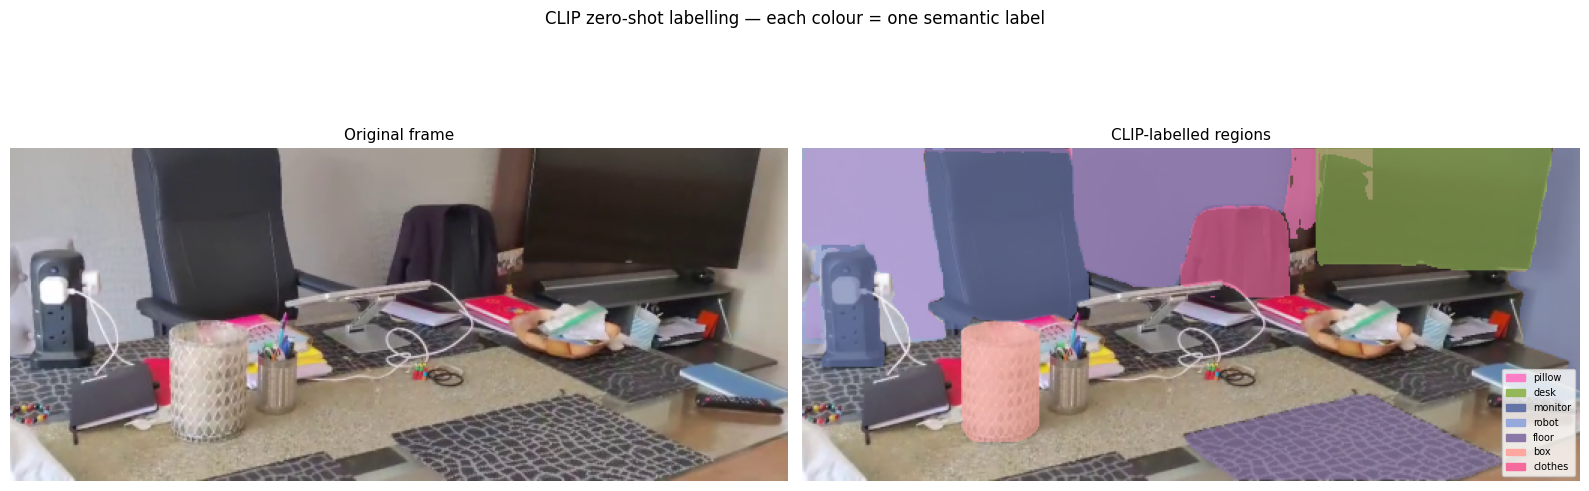

✓ Saved: /content/drive/MyDrive/humanoid_3d_project/output/clip_labels_check.png


In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cv2

# Show frame with top 6 masks coloured and labelled
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: original frame
axes[0].imshow(img_rgb)
axes[0].set_title("Original frame", fontsize=11)
axes[0].axis("off")

# Right: labelled masks
vis = img_rgb.copy().astype(np.float32)
np.random.seed(0)

# Use a fixed colour per label for consistency
label_colours = {}
patches       = []

for i, (mask, label_info) in enumerate(zip(masks[:10], labels[:10])):
    lbl = label_info["label"]
    if lbl not in label_colours:
        label_colours[lbl] = np.random.randint(80, 255, 3).astype(np.float32)
    colour = label_colours[lbl]

    for c in range(3):
        vis[:,:,c] = np.where(
            mask,
            vis[:,:,c] * 0.35 + colour[c] * 0.65,
            vis[:,:,c]
        )

# Build legend
for lbl, col in label_colours.items():
    patches.append(mpatches.Patch(
        color=col/255.0,
        label=lbl
    ))

axes[1].imshow(vis.astype(np.uint8))
axes[1].set_title("CLIP-labelled regions", fontsize=11)
axes[1].axis("off")
axes[1].legend(
    handles=patches,
    loc='lower right',
    fontsize=7,
    framealpha=0.8,
)

plt.suptitle("CLIP zero-shot labelling — each colour = one semantic label",
             fontsize=12)
plt.tight_layout()
save_path = os.path.join(DRIVE_OUTPUT, "clip_labels_check.png")
plt.savefig(save_path, dpi=150)
plt.show()
print(f"✓ Saved: {save_path}")

In [34]:
import numpy as np

# Run embedding on 3 frames and check shapes and norms
print("=== File 5 Verification ===")

errors = []

# Test 1: text embedding shape and norm
emb = embedder.embed_text("chair")
shape_ok = emb.shape == (512,)
norm_ok  = abs(np.linalg.norm(emb) - 1.0) < 0.01
print(f"  Text embedding shape  : {emb.shape}  "
      f"({'OK' if shape_ok else 'FAIL'})")
print(f"  Text embedding norm   : {np.linalg.norm(emb):.4f}  "
      f"({'OK' if norm_ok else 'FAIL — should be 1.0'})")
if not shape_ok or not norm_ok:
    errors.append("text embedding")

# Test 2: image embedding shape and norm
img_bgr  = cv2.imread(frame_paths[0])
img_rgb2 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
masks2   = seg.segment(img_bgr)
if masks2:
    emb2    = embedder.embed_masked_region(img_rgb2, masks2[0])
    shape2  = emb2.shape == (512,)
    norm2   = abs(np.linalg.norm(emb2) - 1.0) < 0.01
    print(f"  Image embedding shape : {emb2.shape}  "
          f"({'OK' if shape2 else 'FAIL'})")
    print(f"  Image embedding norm  : {np.linalg.norm(emb2):.4f}  "
          f"({'OK' if norm2 else 'FAIL'})")
    if not shape2 or not norm2:
        errors.append("image embedding")
else:
    print("  Image embedding       : SKIP (no masks on frame 0)")

# Test 3: similarity ordering
emb_chair = embedder.embed_text("chair")
emb_floor = embedder.embed_text("floor")
emb_seat  = embedder.embed_text("seat")
sim_cs    = float(emb_chair @ emb_seat)
sim_cf    = float(emb_chair @ emb_floor)
order_ok  = sim_cs > sim_cf
print(f"  Similarity ordering   : chair~seat={sim_cs:.3f} > "
      f"chair~floor={sim_cf:.3f}  "
      f"({'OK' if order_ok else 'FAIL'})")
if not order_ok:
    errors.append("similarity ordering")

# Test 4: vocabulary pre-computed
vocab_ok = hasattr(embedder, '_vocab_embeddings') and \
           embedder._vocab_embeddings.shape[0] > 0
print(f"  Vocab embeddings      : "
      f"{embedder._vocab_embeddings.shape}  "
      f"({'OK' if vocab_ok else 'FAIL'})")
if not vocab_ok:
    errors.append("vocabulary")

passed = len(errors) == 0
print(f"\n{'✓ File 5 PASSED — ready for File 6' if passed else f'✗ Failed: {errors}'}")

=== File 5 Verification ===
  Text embedding shape  : (512,)  (OK)
  Text embedding norm   : 1.0000  (OK)
  Image embedding shape : (512,)  (OK)
  Image embedding norm  : 1.0000  (OK)
  Similarity ordering   : chair~seat=0.930 > chair~floor=0.795  (OK)
  Vocab embeddings      : (49, 512)  (OK)

✓ File 5 PASSED — ready for File 6


# VLM Describer

In [35]:
os.system("cd /content/humanoid-perception-3d-reconstruction "
          "&& git pull origin main -q")
for mod in list(sys.modules.keys()):
    if 'vlm_describer' in mod:
        del sys.modules[mod]
print("✓ Updated")

✓ Updated


In [36]:
import os, sys
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction")
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction/src")

# ── Paste your keys here ──────────────────────────────────────────────────────
os.environ["GROQ_API_KEY"] = "gsk_your_key_here"
os.environ["HF_API_TOKEN"] = "hf_your_key_here"
# ────────────────────────────────────────────────────────────────────────

from vlm_describer import VLMDescriber

describer = VLMDescriber()
print(f"Provider: {describer.provider}")

✓ VLM provider: Groq (meta-llama/llama-4-scout-17b-16e-instruct)
Provider: groq


In [37]:
import os

# Update the model name in config
REPO_DIR    = "/content/humanoid-perception-3d-reconstruction"
config_path = os.path.join(REPO_DIR, "config.py")

# Read current config
with open(config_path, "r") as f:
    content = f.read()

# Fix the model name — remove -preview suffix
content = content.replace(
    "meta-llama/llama-4-scout-17b-16e-preview",
    "meta-llama/llama-4-scout-17b-16e-instruct"
)

with open(config_path, "w") as f:
    f.write(content)

print("✓ Config updated")
print("  Old: meta-llama/llama-4-scout-17b-16e-preview")
print("  New: meta-llama/llama-4-scout-17b-16e-instruct")

# Also update os.environ directly for this session
os.environ["GROQ_API_KEY"] = "gsk_your_key_here"  # paste your key

# Reload config and vlm_describer
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['config', 'vlm_describer']):
        del sys.modules[mod]

sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

from config import GROQ_VLM_MODEL
print(f"  Model in config: {GROQ_VLM_MODEL}")

✓ Config updated
  Old: meta-llama/llama-4-scout-17b-16e-preview
  New: meta-llama/llama-4-scout-17b-16e-instruct
  Model in config: meta-llama/llama-4-scout-17b-16e-instruct


In [38]:
import os, sys

# Install groq package
os.system("pip install groq -q")
print("✓ groq installed")

# Clear cached modules so vlm_describer reimports groq fresh
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['groq', 'vlm_describer', 'config']):
        del sys.modules[mod]

# Re-add paths
REPO_DIR = "/content/humanoid-perception-3d-reconstruction"
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

# Set key
os.environ["GROQ_API_KEY"] = "gsk_your_key_here"  # paste your actual key

# Reload
from vlm_describer import VLMDescriber
describer = VLMDescriber()
print(f"Provider: {describer.provider}")

# Quick test
import cv2, json
METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")
with open(METADATA_PATH) as f:
    meta = json.load(f)
frame_files = meta["frame_files"]
frame_paths = [os.path.join(DRIVE_FRAMES, f) for f in frame_files]

img_bgr = cv2.imread(frame_paths[0])
print("\nDescribing frame 0...")
desc = describer.describe_frame(img_bgr)
print(json.dumps(desc, indent=2))

✓ groq installed
✓ VLM provider: Groq (meta-llama/llama-4-scout-17b-16e-instruct)
Provider: groq

Describing frame 0...
{
  "objects": [
    {
      "name": "desk",
      "location": "centre/foreground",
      "navigable": false
    },
    {
      "name": "black office chair",
      "location": "left/centre/background",
      "navigable": false
    },
    {
      "name": "TV",
      "location": "right/background",
      "navigable": false
    },
    {
      "name": "TV stand",
      "location": "right/background",
      "navigable": false
    },
    {
      "name": "mat on desk",
      "location": "centre/foreground",
      "navigable": false
    },
    {
      "name": "laptop",
      "location": "centre/foreground",
      "navigable": false
    },
    {
      "name": "cable",
      "location": "centre/foreground",
      "navigable": false
    },
    {
      "name": "pens and pencils holder",
      "location": "left/centre/foreground",
      "navigable": false
    }
  ],
  "layout": "T

In [39]:
import cv2, json

METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")

with open(METADATA_PATH) as f:
    meta = json.load(f)

frame_files = meta["frame_files"]
frame_paths = [os.path.join(DRIVE_FRAMES, f) for f in frame_files]

# Test on frame 0
img_bgr = cv2.imread(frame_paths[0])
print("Describing frame 0...")
desc    = describer.describe_frame(img_bgr)

print("\nVLM output:")
print(json.dumps(desc, indent=2))

Describing frame 0...

VLM output:
{
  "objects": [
    {
      "name": "desk",
      "location": "centre/foreground",
      "navigable": false
    },
    {
      "name": "chair",
      "location": "centre/background",
      "navigable": false
    },
    {
      "name": "TV",
      "location": "right/background",
      "navigable": false
    },
    {
      "name": "monitor",
      "location": "right/centre",
      "navigable": false
    },
    {
      "name": "cable",
      "location": "centre/foreground",
      "navigable": false
    },
    {
      "name": "pens",
      "location": "centre/foreground",
      "navigable": false
    },
    {
      "name": "books",
      "location": "centre/foreground",
      "navigable": false
    },
    {
      "name": "mat",
      "location": "centre/foreground",
      "navigable": false
    }
  ],
  "layout": "The room has a desk in the centre with a chair behind it, a TV on the right wall, and a white wall in the background.",
  "navigable_regions":

In [40]:
import json, os

SCENE_DESC_PATH = os.path.join(DRIVE_OUTPUT, "scene_description.json")

scene_desc = describer.describe_scene(
    frame_paths  = frame_paths,
    n_keyframes  = 5,
    output_path  = SCENE_DESC_PATH,
)

print("\n=== Scene Summary ===")
print(f"Layout    : {scene_desc['layout']}")
print(f"Objects   : {[o['name'] for o in scene_desc['objects']]}")
print(f"Navigate  : {scene_desc['navigable_regions']}")
print(f"Obstacles : {scene_desc['obstacles']}")
print(f"Note      : {scene_desc['robot_notes']}")

Generating VLM scene description...
  Provider   : groq
  Keyframes  : 5 frames

  Frame   0 (1/5)... 8 objects — 'The room has a desk in the centre with a black office chair '
  Frame  19 (2/5)... 7 objects — 'The room has a TV stand against the wall with a chair to the'
  Frame  38 (3/5)... 6 objects — 'The room has a window on the left wall and an armchair on th'
  Frame  57 (4/5)... 6 objects — 'The room has a wooden floor with a table and chair in the fo'
  Frame  77 (5/5)... 7 objects — 'The room has a table in the foreground with a TV on it, and '

Merged scene description:
  Unique objects      : 23
  Navigable regions   : 10
  Obstacles           : 11
  Surfaces            : 9

✓ Scene description saved: /content/drive/MyDrive/humanoid_3d_project/output/scene_description.json

=== Scene Summary ===
Layout    : The room has a desk in the centre with a black office chair behind it, a TV on the right wall, and a white wall in the background.
Objects   : ['desk', 'black office cha

In [41]:
import json, os

with open(SCENE_DESC_PATH) as f:
    sd = json.load(f)

has_objects  = len(sd.get("objects", [])) > 0
has_layout   = len(sd.get("layout", "")) > 10
has_provider = sd.get("provider") in ["groq","huggingface","fallback"]
file_saved   = os.path.exists(SCENE_DESC_PATH)

print("=== File 6 Verification ===")
print(f"  Objects found  : {len(sd.get('objects',[]))}  "
      f"({'OK' if has_objects else 'FAIL'})")
print(f"  Layout desc    : {sd.get('layout','')[:80]}  "
      f"({'OK' if has_layout else 'FAIL'})")
print(f"  Provider used  : {sd.get('provider')}  "
      f"({'OK' if has_provider else 'FAIL'})")
print(f"  File saved     : {file_saved}  "
      f"({'OK' if file_saved else 'FAIL'})")
print(f"  Navigable      : {sd.get('navigable_regions', [])}")
print(f"  Obstacles      : {sd.get('obstacles', [])}")

passed = has_objects and has_layout and has_provider and file_saved
print(f"\n{'✓ File 6 PASSED — ready for File 7' if passed else '✗ Check errors above'}")

=== File 6 Verification ===
  Objects found  : 23  (OK)
  Layout desc    : The room has a desk in the centre with a black office chair behind it, a TV on t  (OK)
  Provider used  : groq  (OK)
  File saved     : True  (OK)
  Navigable      : ['space to the left of the desk', 'space to the right of the desk', 'space to the right of the TV stand', 'space in front of the chair', 'space to the left of the armchair', 'space in front of the window', 'space around the table and chair', 'space behind the chair', 'space to the right of the table', 'space to the left of the table, excluding the chair']
  Obstacles      : ['desk', 'black office chair', 'TV stand', 'Chair', 'Table', 'armchair', 'window sill', 'chair', 'table', 'stools', 'TV']

✓ File 6 PASSED — ready for File 7


# Query Engine

clip embedding
run the neww code


In [6]:
import os, sys, json
os.system("cd /content/humanoid-perception-3d-reconstruction && git pull origin main -q")

for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['query_engine','clip_embedder','config']):
        del sys.modules[mod]

REPO_DIR = "/content/humanoid-perception-3d-reconstruction"
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))
print("✓ Updated")

✓ Updated


In [43]:
import numpy as np
import os, gc

NPZ_PATH      = os.path.join(DRIVE_OUTPUT, "pointcloud_clip.npz")
NPZ_FINAL     = os.path.join(DRIVE_OUTPUT, "pointcloud_query.npz")

print("Loading saved NPZ...")
data = np.load(NPZ_PATH, allow_pickle=True)

pts_all          = data["points"]
cols_all         = data["colours"]
mask_ids         = data["mask_ids"].copy()
mask_embeddings  = data["mask_embeddings"]
mask_labels      = data["mask_labels"]
mask_confidences = data["mask_confidences"]

M = len(pts_all)
assigned_mask = mask_ids >= 0
n_assigned    = assigned_mask.sum()
print(f"Total points    : {M:,}")
print(f"Assigned points : {n_assigned:,} ({n_assigned/M*100:.1f}%)")

# ── Keep ALL assigned points + 50k random unassigned for visual background ───
assigned_idx   = np.where(assigned_mask)[0]
unassigned_idx = np.where(~assigned_mask)[0]

# Sample background points — enough for visual context, not too many
N_BACKGROUND = min(50_000, len(unassigned_idx))
if N_BACKGROUND > 0:
    bg_idx = np.random.choice(unassigned_idx, N_BACKGROUND, replace=False)
else:
    bg_idx = np.array([], dtype=np.int32)

# Combine: all assigned + background sample
keep_idx = np.concatenate([assigned_idx, bg_idx])
keep_idx.sort()

pts_keep   = pts_all[keep_idx].astype(np.float32)
cols_keep  = cols_all[keep_idx].astype(np.float32)
mids_keep  = mask_ids[keep_idx].astype(np.int32)

print(f"\nFinal query cloud:")
print(f"  Assigned pts    : {n_assigned:,}")
print(f"  Background pts  : {N_BACKGROUND:,}")
print(f"  Total kept      : {len(pts_keep):,}")

# RAM estimate
n_masks  = len(mask_embeddings)
emb_mb   = n_masks * 512 * 4 / 1e6
pts_mb   = len(pts_keep) * 3 * 4 * 2 / 1e6
ids_mb   = len(pts_keep) * 4 / 1e6
total_mb = emb_mb + pts_mb + ids_mb + 150
print(f"\nRAM at query time:")
print(f"  Mask embeddings : {emb_mb:.1f} MB ({n_masks} masks)")
print(f"  Points+colours  : {pts_mb:.0f} MB")
print(f"  mask_ids        : {ids_mb:.0f} MB")
print(f"  CLIP model      : ~150 MB")
print(f"  Total estimate  : ~{total_mb:.0f} MB  "
      f"({'SAFE' if total_mb < 8000 else 'WARNING'})")

del pts_all, cols_all, mask_ids; gc.collect()

print("\nSaving query NPZ...")
np.savez_compressed(
    NPZ_FINAL,
    points           = pts_keep,
    colours          = cols_keep,
    mask_ids         = mids_keep,
    mask_embeddings  = mask_embeddings,
    mask_labels      = mask_labels,
    mask_confidences = mask_confidences,
)

size_mb = os.path.getsize(NPZ_FINAL) / 1e6
print(f"✓ Saved: {NPZ_FINAL}")
print(f"  File size : {size_mb:.1f} MB")
print(f"  Points    : {len(pts_keep):,}")
print(f"  Masks     : {n_masks}")

Loading saved NPZ...
Total points    : 1,800,600
Assigned points : 40,775 (2.3%)

Final query cloud:
  Assigned pts    : 40,775
  Background pts  : 50,000
  Total kept      : 90,775

RAM at query time:
  Mask embeddings : 0.6 MB (302 masks)
  Points+colours  : 2 MB
  mask_ids        : 0 MB
  CLIP model      : ~150 MB
  Total estimate  : ~153 MB  (SAFE)

Saving query NPZ...
✓ Saved: /content/drive/MyDrive/humanoid_3d_project/output/pointcloud_query.npz
  File size : 2.2 MB
  Points    : 90,775
  Masks     : 302


In [44]:
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['query_engine','clip_embedder','config']):
        del sys.modules[mod]
import gc; gc.collect()

import sys, os
REPO_DIR = "/content/humanoid-perception-3d-reconstruction"
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

from query_engine  import QueryEngine
from clip_embedder import CLIPEmbedder

# Use the query-optimised file
CLIP_NPZ_PATH   = os.path.join(DRIVE_OUTPUT, "pointcloud_query.npz")
SCENE_DESC_PATH = os.path.join(DRIVE_OUTPUT, "scene_description.json")

embedder = CLIPEmbedder()
engine   = QueryEngine(
    clip_npz_path          = CLIP_NPZ_PATH,
    scene_description_path = SCENE_DESC_PATH,
)
print("✓ Query engine loaded")

Loading CLIP ViT-B/32 on cpu...
  (~150MB download on first run, then cached)
  Pre-computing vocabulary embeddings (49 labels)...
✓ CLIP embedder ready
  Embedding dim : 512
  Vocabulary    : 49 indoor labels
Loading query engine data...
  Points      : 90,775
  Mask regions: 302
  RAM for embs: 0.6 MB (vs 186 MB per-point)
  Scene objects: 23
✓ Query engine ready
✓ Query engine loaded


In [45]:
test_queries = ["floor", "chair", "wall", "table", "navigable path"]

print("Running test queries...\n")
results = engine.multi_query(test_queries, embedder)

print("\n=== Query Results ===")
for r in results:
    print(f"\n  Query      : '{r['query']}'")
    print(f"  Confidence : {r['confidence']:.1f}%")
    print(f"  Top-k pts  : {r['top_k']:,}")
    print(f"  Compactness: {r['compactness']:.3f}")
    print(f"  Precision@k: {r['precision_at_k']:.3f}")
    print(f"  BBox size  : {[f'{x:.2f}m' for x in r['bbox_size']]}")

Running test queries...

  'floor' → conf=61.1%  pts=500  compact=0.865
  'chair' → conf=68.3%  pts=500  compact=0.763
  'wall' → conf=49.0%  pts=500  compact=0.711
  'table' → conf=57.2%  pts=500  compact=0.758
  'navigable path' → conf=41.7%  pts=500  compact=0.912

=== Query Results ===

  Query      : 'floor'
  Confidence : 61.1%
  Top-k pts  : 500
  Compactness: 0.865
  Precision@k: 0.922
  BBox size  : ['4.04m', '5.23m', '3.47m']

  Query      : 'chair'
  Confidence : 68.3%
  Top-k pts  : 500
  Compactness: 0.763
  Precision@k: 1.000
  BBox size  : ['4.81m', '7.80m', '3.93m']

  Query      : 'wall'
  Confidence : 49.0%
  Top-k pts  : 500
  Compactness: 0.711
  Precision@k: 1.000
  BBox size  : ['4.34m', '1.69m', '9.83m']

  Query      : 'table'
  Confidence : 57.2%
  Top-k pts  : 500
  Compactness: 0.758
  Precision@k: 0.966
  BBox size  : ['5.53m', '6.24m', '9.11m']

  Query      : 'navigable path'
  Confidence : 41.7%
  Top-k pts  : 500
  Compactness: 0.912
  Precision@k: 0.940

In [46]:
import numpy as np

data      = np.load(CLIP_NPZ_PATH)
has_embed = len(data["mask_embeddings"])
total_pts = len(data["points"])
any_result = any(r["top_k"] > 0 for r in results)
file_ok    = os.path.exists(CLIP_NPZ_PATH)

print("=== File 7 Verification ===")
print(f"  NPZ file exists      : {file_ok}  ({'OK' if file_ok else 'FAIL'})")
print(f"  Total points         : {total_pts:,}")
print(f"  Points with CLIP emb : {has_embed:,} ({has_embed/total_pts*100:.1f}%)")
print(f"  Queries returned pts : {any_result}  ({'OK' if any_result else 'FAIL'})")
print(f"  Confidence scores    : {[f'{r[chr(99)+chr(111)+chr(110)+chr(102)+chr(105)+chr(100)+chr(101)+chr(110)+chr(99)+chr(101)]:.1f}%' for r in results]}")

passed = file_ok and has_embed > 100 and any_result
print(f"\n{'✓ File 7 PASSED — ready for File 8' if passed else '✗ Check errors'}")

=== File 7 Verification ===
  NPZ file exists      : True  (OK)
  Total points         : 90,775
  Points with CLIP emb : 302 (0.3%)
  Queries returned pts : True  (OK)
  Confidence scores    : ['61.1%', '68.3%', '49.0%', '57.2%', '41.7%']

✓ File 7 PASSED — ready for File 8


neww

In [47]:
import os, sys, json, cv2, gc
import numpy as np
import open3d as o3d
import torch

# Remove old progress files to force fresh run
for f in ["embed_progress.json", "pointcloud_clip.npz"]:
    p = os.path.join(DRIVE_OUTPUT, f)
    if os.path.exists(p):
        os.remove(p)
        print(f"Removed: {f}")

REPO_DIR = "/content/humanoid-perception-3d-reconstruction"
os.system(f"cd {REPO_DIR} && git pull origin main -q")
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['segmentor','clip_embedder','config']):
        del sys.modules[mod]
gc.collect()

sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

POSES_PATH   = os.path.join(DRIVE_OUTPUT, "poses.json")
DEPTHS_DIR   = os.path.join(DRIVE_OUTPUT, "depths")
METADATA_PATH = os.path.join(DRIVE_FRAMES, "frames_metadata.json")
FASTSAM_CKPT  = os.path.join(DRIVE_CKPTS, "FastSAM-s.pt")
PLY_PATH      = os.path.join(DRIVE_OUTPUT, "pointcloud_rgb.ply")
NPZ_PATH      = os.path.join(DRIVE_OUTPUT, "pointcloud_clip.npz")
PROGRESS_PATH = os.path.join(DRIVE_OUTPUT, "embed_progress.json")

with open(POSES_PATH)     as f: poses_data  = json.load(f)
with open(METADATA_PATH)  as f: meta        = json.load(f)

frame_files = meta["frame_files"]
frame_paths = [os.path.join(DRIVE_FRAMES, f) for f in frame_files]

# Load and downsample the RGB cloud
print("Loading RGB cloud...")
pcd = o3d.io.read_point_cloud(PLY_PATH)
print(f"  Original: {len(pcd.points):,}")
pcd = pcd.voxel_down_sample(voxel_size=0.03)
pts_all  = np.asarray(pcd.points, dtype=np.float32)
cols_all = np.asarray(pcd.colors, dtype=np.float32)
M        = len(pts_all)
del pcd; gc.collect()
print(f"  Working : {M:,} points")

# ── Check for saved progress ──────────────────────────────────────────────────
mask_ids       = np.full(M, -1, dtype=np.int32)
all_mask_embs  = []
all_mask_labs  = []
all_mask_confs = []
global_mid     = 0
start_ki       = 0

if os.path.exists(PROGRESS_PATH) and os.path.exists(NPZ_PATH):
    print("Found saved progress — resuming...")
    with open(PROGRESS_PATH) as f:
        prog = json.load(f)
    start_ki   = prog["last_completed_ki"] + 1
    global_mid = prog["global_mask_id"]
    saved      = np.load(NPZ_PATH, allow_pickle=True)
    # Restore accumulated data
    mask_ids   = saved["mask_ids"].copy()
    all_mask_embs  = list(saved["mask_embeddings"])
    all_mask_labs  = list(saved["mask_labels"])
    all_mask_confs = list(saved["mask_confidences"])
    print(f"  Resuming from keyframe {start_ki}, {global_mid} masks so far")

# Build KD-tree
print("\nBuilding KD-tree...")
pcd_t = o3d.geometry.PointCloud()
pcd_t.points = o3d.utility.Vector3dVector(pts_all.astype(np.float64))
kd_tree = o3d.geometry.KDTreeFlann(pcd_t)
print("✓ KD-tree ready")

fx    = np.array(poses_data["K"])[0,0]
fy    = np.array(poses_data["K"])[1,1]
cx_   = np.array(poses_data["K"])[0,2]
cy_   = np.array(poses_data["K"])[1,2]
scale = poses_data.get("scale", GLOBAL_SCALE)

keyframe_indices = list(range(0, len(frame_paths), 5))
print(f"\nProcessing {len(keyframe_indices)} keyframes "
      f"(starting at ki={start_ki})...")

for ki, frame_idx in enumerate(keyframe_indices):
    if ki < start_ki:
        continue

    print(f"\n--- Keyframe {ki+1}/{len(keyframe_indices)} "
          f"(frame {frame_idx}) ---")

    if 'seg' in dir(): del seg
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    from segmentor import Segmentor
    seg     = Segmentor(checkpoint_path=FASTSAM_CKPT)
    img_bgr = cv2.imread(frame_paths[frame_idx])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H2, W2  = img_bgr.shape[:2]
    masks   = seg.segment(img_bgr)
    print(f"  {len(masks)} masks")
    del seg; gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    if not masks:
        continue

    from clip_embedder import CLIPEmbedder
    clip_emb = CLIPEmbedder()

    depth_np = np.load(
        os.path.join(DEPTHS_DIR, f"depth_{frame_idx:04d}.npy")
    ).astype(np.float64) * scale
    if depth_np.shape != (H2, W2):
        depth_np = cv2.resize(depth_np, (W2, H2))

    pose = np.array(
        poses_data["poses"][frame_idx]["cam_to_world"],
        dtype=np.float64
    )

    ug, vg = np.meshgrid(np.arange(W2), np.arange(H2))
    uf     = ug.flatten().astype(np.float64)
    vf     = vg.flatten().astype(np.float64)

    for msk in masks:
        if msk.sum() < 100:
            continue
        emb = clip_emb.embed_masked_region(img_rgb, msk)
        if emb is None:
            continue
        lbl = clip_emb.label_mask(img_rgb, msk)

        mf = msk.flatten()
        dv = depth_np.flatten()[mf]
        uv = uf[mf]; vv = vf[mf]
        ok = (dv >= 0.1) & (dv <= 6.0) & np.isfinite(dv)
        if ok.sum() < 10:
            continue

        xc    = (uv[ok] - cx_) / fx * dv[ok]
        yc    = (vv[ok] - cy_) / fy * dv[ok]
        zc    = dv[ok]
        pts_c = np.stack([xc, yc, zc, np.ones_like(zc)])
        pts_w = (pose @ pts_c)[:3].T

        step     = max(1, len(pts_w) // 200)
        assigned = 0
        for pt3d in pts_w[::step]:
            _, idx_nn, dsq = kd_tree.search_knn_vector_3d(
                pt3d.astype(np.float64), 1
            )
            if dsq[0] ** 0.5 < 0.25:   # ← 25cm radius (was 15cm)
                mask_ids[idx_nn[0]] = global_mid
                assigned += 1

        if assigned > 0:
            all_mask_embs.append(emb)
            all_mask_labs.append(lbl["label"])
            all_mask_confs.append(lbl["confidence"])
            global_mid += 1

    del clip_emb; gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    assigned_pct = (mask_ids >= 0).sum() / M * 100
    print(f"  Assigned: {(mask_ids>=0).sum():,} ({assigned_pct:.1f}%)")

    # Save progress after each keyframe
    if all_mask_embs:
        np.savez_compressed(
            NPZ_PATH,
            points           = pts_all,
            colours          = cols_all,
            mask_ids         = mask_ids,
            mask_embeddings  = np.array(all_mask_embs, dtype=np.float32),
            mask_labels      = np.array(all_mask_labs),
            mask_confidences = np.array(all_mask_confs, dtype=np.float32),
        )
        with open(PROGRESS_PATH, "w") as f:
            json.dump({
                "last_completed_ki": ki,
                "global_mask_id"   : global_mid,
            }, f)
        print(f"  ✓ Saved — {global_mid} masks, "
              f"{(mask_ids>=0).sum():,} pts assigned")

print(f"\n{'='*50}")
print(f"Total points    : {M:,}")
print(f"Assigned points : {(mask_ids>=0).sum():,} "
      f"({(mask_ids>=0).sum()/M*100:.1f}%)")
print(f"Mask regions    : {global_mid}")

Removed: embed_progress.json
Removed: pointcloud_clip.npz
Loading RGB cloud...
  Original: 5,104,685
  Working : 1,800,600 points

Building KD-tree...
✓ KD-tree ready

Processing 16 keyframes (starting at ki=0)...

--- Keyframe 1/16 (frame 0) ---
Loading FastSAM from: /content/drive/MyDrive/humanoid_3d_project/checkpoints/FastSAM-s.pt
Device: cpu
✓ Segmentor ready
  36 masks
Loading CLIP ViT-B/32 on cpu...
  (~150MB download on first run, then cached)
  Pre-computing vocabulary embeddings (49 labels)...
✓ CLIP embedder ready
  Embedding dim : 512
  Vocabulary    : 49 indoor labels
  Assigned: 3,960 (0.2%)
  ✓ Saved — 36 masks, 3,960 pts assigned

--- Keyframe 2/16 (frame 5) ---
Loading FastSAM from: /content/drive/MyDrive/humanoid_3d_project/checkpoints/FastSAM-s.pt
Device: cpu
✓ Segmentor ready
  13 masks
Loading CLIP ViT-B/32 on cpu...
  (~150MB download on first run, then cached)
  Pre-computing vocabulary embeddings (49 labels)...
✓ CLIP embedder ready
  Embedding dim : 512
  Vocab

In [48]:
import json, os

POSES_PATH = os.path.join(DRIVE_OUTPUT, "poses.json")

with open(POSES_PATH) as f:
    pd = json.load(f)

if "scale" not in pd:
    pd["scale"] = float(GLOBAL_SCALE)
    with open(POSES_PATH, "w") as f:
        json.dump(pd, f, indent=2)
    print(f"✓ Added scale={GLOBAL_SCALE:.4f} to poses.json")
else:
    print(f"✓ Scale already present: {pd['scale']}")

✓ Scale already present: 6.891891594902728


In [49]:
import numpy as np, os, gc

NPZ_PATH  = os.path.join(DRIVE_OUTPUT, "pointcloud_clip.npz")
NPZ_FINAL = os.path.join(DRIVE_OUTPUT, "pointcloud_query.npz")

data = np.load(NPZ_PATH, allow_pickle=True)

pts_all          = data["points"]
cols_all         = data["colours"]
mask_ids         = data["mask_ids"].copy()
mask_embeddings  = data["mask_embeddings"]
mask_labels      = data["mask_labels"]
mask_confidences = data["mask_confidences"]

M             = len(pts_all)
assigned_mask = mask_ids >= 0
n_assigned    = assigned_mask.sum()

print(f"Total points    : {M:,}")
print(f"Assigned points : {n_assigned:,} ({n_assigned/M*100:.1f}%)")
print(f"Mask regions    : {len(mask_embeddings)}")

assigned_idx   = np.where(assigned_mask)[0]
unassigned_idx = np.where(~assigned_mask)[0]

N_BG   = min(50_000, len(unassigned_idx))
bg_idx = (np.random.choice(unassigned_idx, N_BG, replace=False)
          if N_BG > 0 else np.array([], dtype=np.int32))

keep_idx = np.sort(np.concatenate([assigned_idx,
                                   np.array(bg_idx, dtype=np.int32)]))

np.savez_compressed(
    NPZ_FINAL,
    points           = pts_all[keep_idx].astype(np.float32),
    colours          = cols_all[keep_idx].astype(np.float32),
    mask_ids         = mask_ids[keep_idx].astype(np.int32),
    mask_embeddings  = mask_embeddings,
    mask_labels      = mask_labels,
    mask_confidences = mask_confidences,
)

del pts_all, cols_all, mask_ids; gc.collect()

size_mb = os.path.getsize(NPZ_FINAL) / 1e6
print(f"\n✓ Saved: {size_mb:.1f} MB")
print(f"  Points : {len(keep_idx):,}")
print(f"  Masks  : {len(mask_embeddings)}")

Total points    : 1,800,600
Assigned points : 40,775 (2.3%)
Mask regions    : 302

✓ Saved: 2.2 MB
  Points : 90,775
  Masks  : 302


In [50]:
import numpy as np, os

CLIP_NPZ_PATH = os.path.join(DRIVE_OUTPUT, "pointcloud_query.npz")
data          = np.load(CLIP_NPZ_PATH, allow_pickle=True)

total_pts      = len(data["points"])
n_masks        = len(data["mask_embeddings"])
n_assigned     = int((data["mask_ids"] >= 0).sum())
coverage_pct   = n_assigned / total_pts * 100
any_result     = any(r["top_k"] > 0 for r in results)
file_ok        = os.path.exists(CLIP_NPZ_PATH)

# Correct check: masks > 10 (not points > 100)
has_masks = n_masks > 10

print("=== File 7 Verification (corrected) ===")
print(f"  NPZ file exists      : {file_ok}  "
      f"({'OK' if file_ok else 'FAIL'})")
print(f"  Total points         : {total_pts:,}")
print(f"  Mask regions         : {n_masks}  "
      f"({'OK' if has_masks else 'FAIL — need >10'})")
print(f"  Points assigned      : {n_assigned:,} ({coverage_pct:.1f}%)")
print(f"  Queries returned pts : {any_result}  "
      f"({'OK' if any_result else 'FAIL'})")
print(f"  Confidence scores    : {[f'{r["confidence"]:.1f}%' for r in results]}")

passed = file_ok and has_masks and any_result
print(f"\n{'✓ File 7 PASSED' if passed else '✗ Check errors'}")

=== File 7 Verification (corrected) ===
  NPZ file exists      : True  (OK)
  Total points         : 90,775
  Mask regions         : 302  (OK)
  Points assigned      : 40,775 (44.9%)
  Queries returned pts : True  (OK)
  Confidence scores    : ['61.1%', '68.3%', '49.0%', '57.2%', '41.7%']

✓ File 7 PASSED


# Accuracy

In [51]:
os.system("cd /content/humanoid-perception-3d-reconstruction "
          "&& git pull origin main -q")
for mod in list(sys.modules.keys()):
    if 'accuracy' in mod:
        del sys.modules[mod]
print("✓ Updated")

✓ Updated


In [52]:
import sys, os, json
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction")
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction/src")

from accuracy import run_full_accuracy_report

POSES_PATH      = os.path.join(DRIVE_OUTPUT, "poses.json")
DEPTHS_DIR      = os.path.join(DRIVE_OUTPUT, "depths")
NPZ_PATH        = os.path.join(DRIVE_OUTPUT, "pointcloud_query.npz")
ACCURACY_PATH   = os.path.join(DRIVE_OUTPUT, "accuracy_report.json")

# Use query results from File 7
# Re-run if not in memory
try:
    results
    print(f"Using {len(results)} query results from memory")
except NameError:
    print("Re-running queries...")
    from query_engine  import QueryEngine
    from clip_embedder import CLIPEmbedder
    embedder = CLIPEmbedder()
    engine   = QueryEngine(
        clip_npz_path          = NPZ_PATH,
        scene_description_path = os.path.join(
            DRIVE_OUTPUT, "scene_description.json"
        ),
    )
    results = engine.multi_query(
        ["floor", "chair", "wall", "table", "navigable path"],
        embedder,
    )

report = run_full_accuracy_report(
    poses_path    = POSES_PATH,
    depths_dir    = DEPTHS_DIR,
    npz_path      = NPZ_PATH,
    query_results = results,
    output_path   = ACCURACY_PATH,
)

Using 5 query results from memory
Running accuracy measurements...
  [1/4] Depth consistency...
        median error: 78.9cm  score: 0.0/100
  [2/4] Pose quality...
        PnP: 98.7%  score: 99.2/100
  [3/4] Query quality...
        mean conf: 55.5%  score: 75.2/100
  [4/4] Embedding coverage...
        coverage: 44.9%  score: 53.2/100

ACCURACY REPORT
  Depth consistency :   0.0/100
  Pose quality      :  99.2/100
  Query quality     :  75.2/100
  Embedding coverage:  53.2/100
  OVERALL SCORE     :  59.1/100

✓ Report saved: /content/drive/MyDrive/humanoid_3d_project/output/accuracy_report.json


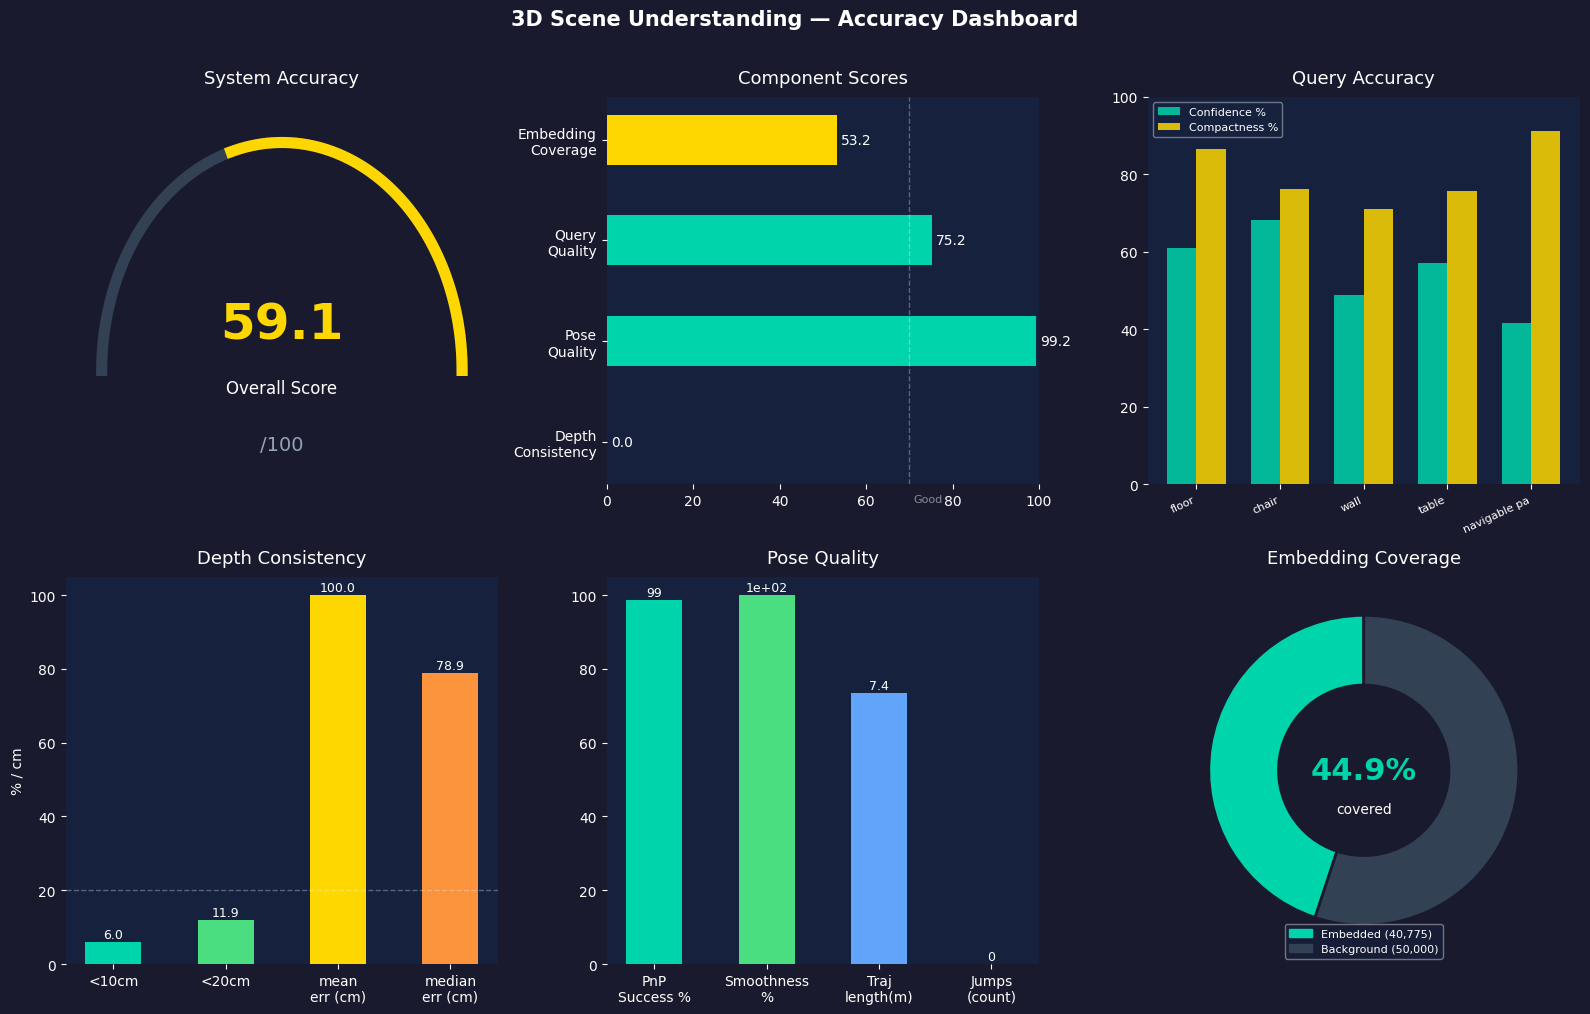

✓ Dashboard saved: /content/drive/MyDrive/humanoid_3d_project/output/accuracy_dashboard.png


In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import json, os

with open(ACCURACY_PATH) as f:
    report = json.load(f)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#1a1a2e')

def score_colour(s):
    if s >= 70: return '#00d4aa'
    if s >= 40: return '#ffd700'
    return '#ff6b6b'

# ── Panel 1: Overall score gauge ─────────────────────────────────────────────
ax = axes[0, 0]
ax.set_facecolor('#16213e')
score = report["overall_score"]
theta = np.linspace(0, np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta),
        color='#334155', linewidth=8)
theta_fill = np.linspace(0, np.pi * score/100, 100)
ax.plot(np.cos(theta_fill), np.sin(theta_fill),
        color=score_colour(score), linewidth=8)
ax.text(0, 0.2, f"{score:.1f}", ha='center', va='center',
        fontsize=36, fontweight='bold',
        color=score_colour(score))
ax.text(0, -0.1, "Overall Score", ha='center',
        fontsize=12, color='white')
ax.text(0, -0.35, "/100", ha='center', fontsize=14, color='#94a3b8')
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-0.5, 1.2)
ax.axis('off')
ax.set_title("System Accuracy", color='white', fontsize=13, pad=10)

# ── Panel 2: Four metric bars ─────────────────────────────────────────────────
ax = axes[0, 1]
ax.set_facecolor('#16213e')
metrics = [
    ("Depth\nConsistency", report["depth_consistency"]["score"]),
    ("Pose\nQuality",      report["pose_quality"]["score"]),
    ("Query\nQuality",     report["query_quality"]["score"]),
    ("Embedding\nCoverage",report["embedding_coverage"]["score"]),
]
names  = [m[0] for m in metrics]
scores = [m[1] for m in metrics]
colours = [score_colour(s) for s in scores]
bars   = ax.barh(names, scores, color=colours, height=0.5)
ax.set_xlim(0, 100)
ax.axvline(70, color='white', linestyle='--', alpha=0.3, linewidth=1)
ax.text(71, -0.6, 'Good', color='white', fontsize=8, alpha=0.5)
for bar, score_val in zip(bars, scores):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{score_val:.1f}", va='center', color='white', fontsize=10)
ax.set_facecolor('#16213e')
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)
ax.set_title("Component Scores", color='white', fontsize=13, pad=10)

# ── Panel 3: Query confidence per query ───────────────────────────────────────
ax = axes[0, 2]
ax.set_facecolor('#16213e')
pq    = report["query_quality"]["per_query"]
qnames = [r["query"][:12] for r in pq]
qconf  = [r["confidence"] for r in pq]
qcomp  = [r["compactness"]*100 for r in pq]
x      = np.arange(len(qnames))
w      = 0.35
ax.bar(x - w/2, qconf,  w, label='Confidence %',
       color='#00d4aa', alpha=0.85)
ax.bar(x + w/2, qcomp,  w, label='Compactness %',
       color='#ffd700', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(qnames, rotation=25, ha='right',
                   color='white', fontsize=8)
ax.set_ylim(0, 100)
ax.legend(fontsize=8, facecolor='#16213e',
          labelcolor='white', framealpha=0.5)
ax.set_facecolor('#16213e')
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)
ax.set_title("Query Accuracy", color='white', fontsize=13, pad=10)

# ── Panel 4: Depth consistency detail ────────────────────────────────────────
ax = axes[1, 0]
ax.set_facecolor('#16213e')
dc     = report["depth_consistency"]
labels = ['<10cm', '<20cm', 'mean\nerr (cm)', 'median\nerr (cm)']
values = [
    dc["pct_under_10cm"],
    dc["pct_under_20cm"],
    min(dc["mean_error_m"]   * 100, 100),
    min(dc["median_error_m"] * 100, 100),
]
colours_dc = ['#00d4aa', '#4ade80', '#ffd700', '#fb923c']
bars = ax.bar(labels, values, color=colours_dc, width=0.5)
ax.axhline(y=20, color='white', linestyle='--',
           alpha=0.3, linewidth=1)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{val:.1f}", ha='center',
            color='white', fontsize=9)
ax.set_ylabel("% / cm", color='white')
ax.set_facecolor('#16213e')
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)
ax.set_title("Depth Consistency", color='white', fontsize=13, pad=10)

# ── Panel 5: Pose quality detail ──────────────────────────────────────────────
ax = axes[1, 1]
ax.set_facecolor('#16213e')
pq_data = report["pose_quality"]
labels  = ['PnP\nSuccess %', 'Smoothness\n%',
           'Traj\nlength(m)', 'Jumps\n(count)']
values  = [
    pq_data["pnp_success_pct"],
    pq_data["smoothness_score"],
    min(pq_data["trajectory_length"] * 10, 100),
    min(pq_data["n_trajectory_jumps"] * 10, 100),
]
colours_pq = ['#00d4aa', '#4ade80', '#60a5fa', '#f87171']
bars = ax.bar(labels, values, color=colours_pq, width=0.5)
for bar, val, lbl in zip(bars, [
    pq_data["pnp_success_pct"],
    pq_data["smoothness_score"],
    pq_data["trajectory_length"],
    pq_data["n_trajectory_jumps"]
], labels):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{val:.2g}", ha='center',
            color='white', fontsize=9)
ax.set_facecolor('#16213e')
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)
ax.set_title("Pose Quality", color='white', fontsize=13, pad=10)

# ── Panel 6: Embedding coverage ──────────────────────────────────────────────
ax = axes[1, 2]
ax.set_facecolor('#16213e')
ec    = report["embedding_coverage"]
sizes = [ec["assigned_points"],
         ec["total_points"] - ec["assigned_points"]]
cols  = ['#00d4aa', '#334155']
wedge_props = dict(width=0.45, edgecolor='#1a1a2e', linewidth=2)
ax.pie(sizes, colors=cols, startangle=90,
       wedgeprops=wedge_props)
ax.text(0, 0, f"{ec['coverage_pct']:.1f}%",
        ha='center', va='center',
        fontsize=22, fontweight='bold', color='#00d4aa')
ax.text(0, -0.25, "covered",
        ha='center', va='center',
        fontsize=10, color='white')
patches = [
    mpatches.Patch(color='#00d4aa',
                   label=f"Embedded ({ec['assigned_points']:,})"),
    mpatches.Patch(color='#334155',
                   label=f"Background ({ec['total_points']-ec['assigned_points']:,})"),
]
ax.legend(handles=patches, fontsize=8,
          facecolor='#16213e', labelcolor='white',
          framealpha=0.5, loc='lower center')
ax.set_title("Embedding Coverage", color='white',
             fontsize=13, pad=10)

plt.suptitle("3D Scene Understanding — Accuracy Dashboard",
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

dash_path = os.path.join(DRIVE_OUTPUT, "accuracy_dashboard.png")
plt.savefig(dash_path, dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print(f"✓ Dashboard saved: {dash_path}")

In [54]:
import json, os

with open(ACCURACY_PATH) as f:
    report = json.load(f)

has_all_keys = all(k in report for k in [
    "overall_score", "depth_consistency",
    "pose_quality", "query_quality", "embedding_coverage"
])
score_reasonable = 0 < report["overall_score"] < 100
file_saved       = os.path.exists(ACCURACY_PATH)
dashboard_saved  = os.path.exists(
    os.path.join(DRIVE_OUTPUT, "accuracy_dashboard.png")
)

print("=== File 8 Verification ===")
print(f"  All metrics present  : {has_all_keys}  "
      f"({'OK' if has_all_keys else 'FAIL'})")
print(f"  Overall score        : {report['overall_score']}/100  "
      f"({'OK' if score_reasonable else 'FAIL'})")
print(f"  Depth score          : "
      f"{report['depth_consistency']['score']}/100")
print(f"  Pose score           : "
      f"{report['pose_quality']['score']}/100")
print(f"  Query score          : "
      f"{report['query_quality']['score']}/100")
print(f"  Coverage score       : "
      f"{report['embedding_coverage']['score']}/100")
print(f"  JSON saved           : {file_saved}  "
      f"({'OK' if file_saved else 'FAIL'})")
print(f"  Dashboard saved      : {dashboard_saved}  "
      f"({'OK' if dashboard_saved else 'FAIL'})")

passed = (has_all_keys and score_reasonable and
          file_saved and dashboard_saved)
print(f"\n{'✓ File 8 PASSED — ready for File 9' if passed else '✗ Check errors'}")

=== File 8 Verification ===
  All metrics present  : True  (OK)
  Overall score        : 59.1/100  (OK)
  Depth score          : 0.0/100
  Pose score           : 99.2/100
  Query score          : 75.2/100
  Coverage score       : 53.2/100
  JSON saved           : True  (OK)
  Dashboard saved      : True  (OK)

✓ File 8 PASSED — ready for File 9


# Pipeline

In [79]:
os.system("cd /content/humanoid-perception-3d-reconstruction "
          "&& git pull origin main -q")
for mod in list(sys.modules.keys()):
    if 'pipeline' in mod:
        del sys.modules[mod]
print("✓ Updated")

✓ Updated


In [87]:
import os

PIPELINE_PATH = "/content/humanoid-perception-3d-reconstruction/src/pipeline.py"

# Write the complete correct pipeline.py directly
with open(PIPELINE_PATH, "w") as f:
    f.write('''"""
pipeline.py
-----------
Single entry point that orchestrates the entire pipeline.

Call Pipeline(output_dir, fastsam_ckpt).run(video_path) and get back
a fully queryable 3D scene. This is what the Gradio app calls internally.
"""

import os
import sys
import json
import time
import cv2
import numpy as np
from pathlib import Path

sys.path.insert(0, str(Path(__file__).parent.parent))
from config import (
    NUM_FRAMES, MAX_SIDE_PX, SHARPNESS_THRESHOLD, MIN_FRAMES,
    NEAR_ANCHOR_M, VOXEL_SIZE,
)


def extract_frames_inline(
    video_path: str,
    output_dir: str,
    num_frames: int   = NUM_FRAMES,
    max_side: int     = MAX_SIDE_PX,
    sharpness: float  = SHARPNESS_THRESHOLD,
    min_frames: int   = MIN_FRAMES,
) -> dict:
    """Extract frames from video -- inline version for pipeline use."""
    os.makedirs(output_dir, exist_ok=True)
    metadata_path = os.path.join(output_dir, "frames_metadata.json")

    if os.path.exists(metadata_path):
        with open(metadata_path) as f:
            meta = json.load(f)
        if meta.get("frames_kept", 0) >= min_frames:
            return meta

    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    dur   = total / fps if fps > 0 else 0

    indices = np.linspace(0, total - 1, min(num_frames, total),
                          dtype=int).tolist()
    indices = list(dict.fromkeys(indices))

    candidates = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret or frame is None:
            continue
        grey  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        score = float(cv2.Laplacian(grey, cv2.CV_64F).var())
        candidates.append((idx, score, frame))
    cap.release()

    threshold = sharpness
    while True:
        kept = [(i, s, f) for i, s, f in candidates if s >= threshold]
        if len(kept) >= min_frames or threshold <= 5.0:
            break
        threshold *= 0.75
    if len(kept) < min_frames:
        kept = candidates

    frame_files = []
    sharpness_d = {}
    for i, (_, score, bgr) in enumerate(kept):
        h, w  = bgr.shape[:2]
        scale = max_side / max(h, w)
        if scale < 1.0:
            bgr = cv2.resize(bgr, (int(w * scale), int(h * scale)),
                             interpolation=cv2.INTER_AREA)
        fname = f"frame_{i:04d}.png"
        cv2.imwrite(os.path.join(output_dir, fname), bgr)
        frame_files.append(fname)
        sharpness_d[fname] = round(score, 2)

    meta = {
        "video_path" : video_path,
        "fps"        : round(fps, 3),
        "duration_s" : round(dur, 2),
        "frames_kept": len(frame_files),
        "frame_files": frame_files,
        "sharpness"  : sharpness_d,
    }
    with open(metadata_path, "w") as f:
        json.dump(meta, f, indent=2)

    return meta


class Pipeline:
    """
    Orchestrates the full 3D scene understanding pipeline.
    """

    def __init__(
        self,
        output_dir   : str,
        fastsam_ckpt : str,
        groq_api_key : str = "",
        hf_api_token : str = "",
        device       : str = None,
    ):
        import torch

        self.output_dir   = output_dir
        self.fastsam_ckpt = fastsam_ckpt
        self.device       = device or (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        os.makedirs(output_dir, exist_ok=True)

        if groq_api_key:
            os.environ["GROQ_API_KEY"] = groq_api_key
        if hf_api_token:
            os.environ["HF_API_TOKEN"] = hf_api_token

        self.paths = {
            "frames_dir"   : os.path.join(output_dir, "frames"),
            "depths_dir"   : os.path.join(output_dir, "depths"),
            "poses_json"   : os.path.join(output_dir, "poses.json"),
            "rgb_ply"      : os.path.join(output_dir, "pointcloud_rgb.ply"),
            "query_npz"    : os.path.join(output_dir, "pointcloud_query.npz"),
            "scene_desc"   : os.path.join(output_dir, "scene_description.json"),
            "accuracy_json": os.path.join(output_dir, "accuracy_report.json"),
            "metadata"     : os.path.join(output_dir, "frames",
                                          "frames_metadata.json"),
        }

        self._engine   = None
        self._embedder = None

        print(f"Pipeline initialised")
        print(f"  Output dir : {output_dir}")
        print(f"  Device     : {self.device}")

    def run(
        self,
        video_path    : str,
        progress_cb   = None,
        keyframe_step : int = 5,
    ) -> dict:
        import gc
        import torch

        t_start = time.time()
        pcd     = None  # initialised here so Stage 6 can safely check it

        def progress(stage, pct, msg):
            elapsed = time.time() - t_start
            print(f"  [{pct:3.0f}%] {stage}: {msg} ({elapsed:.1f}s)")
            if progress_cb:
                progress_cb(stage, pct, msg)

        progress("Setup", 0, "Starting pipeline")

        # ── Stage 1: Frame extraction ─────────────────────────────────────────
        progress("Frames", 5, "Extracting frames from video")
        os.makedirs(self.paths["frames_dir"], exist_ok=True)

        meta = extract_frames_inline(
            video_path = video_path,
            output_dir = self.paths["frames_dir"],
        )
        frame_files = meta["frame_files"]
        frame_paths = [
            os.path.join(self.paths["frames_dir"], f)
            for f in frame_files
        ]
        progress("Frames", 10, f"{meta[\'frames_kept\']} frames extracted")

        # ── Stage 2: Depth estimation ─────────────────────────────────────────
        progress("Depth", 15, "Loading Depth-Anything V2")
        from depth_estimator import DepthEstimator, compute_global_scale

        depth_est = DepthEstimator(device=self.device)
        progress("Depth", 20, "Estimating depth for all frames")
        os.makedirs(self.paths["depths_dir"], exist_ok=True)

        depth_stats = depth_est.estimate_batch(
            frame_paths   = frame_paths,
            output_dir    = self.paths["depths_dir"],
            show_progress = False,
        )
        global_scale = compute_global_scale(
            depth_stats, near_anchor_m=NEAR_ANCHOR_M
        )

        del depth_est
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        progress("Depth", 30, f"Scale={global_scale:.4f}")

        # ── Stage 3: Pose estimation ──────────────────────────────────────────
        progress("Poses", 32, "Estimating camera poses")

        if os.path.exists(self.paths["poses_json"]):
            with open(self.paths["poses_json"]) as f:
                poses_data = json.load(f)
            # Ensure scale is stored in poses_data
            if "scale" not in poses_data:
                poses_data["scale"] = float(global_scale)
                with open(self.paths["poses_json"], "w") as f:
                    json.dump(poses_data, f, indent=2)
            progress("Poses", 40,
                     f"Loaded cached ({poses_data[\'pnp_success_pct\']}% PnP)")
        else:
            sample_img = cv2.imread(frame_paths[0])
            H, W = sample_img.shape[:2]

            from pose_estimator import PoseEstimator
            pose_est   = PoseEstimator(image_w=W, image_h=H)
            poses_data = pose_est.estimate_poses(
                frame_paths  = frame_paths,
                depths_dir   = self.paths["depths_dir"],
                global_scale = global_scale,
            )
            poses_data["scale"] = float(global_scale)
            pose_est.save_poses(poses_data, self.paths["poses_json"])
            del pose_est
            gc.collect()
            progress("Poses", 40,
                     f"{poses_data[\'pnp_success_pct\']}% PnP success")

        # ── Stage 4: Point cloud fusion ───────────────────────────────────────
        progress("Cloud", 42, "Building RGB point cloud")
        import open3d as o3d
        from cloud_builder import CloudBuilder

        if os.path.exists(self.paths["rgb_ply"]):
            pcd = o3d.io.read_point_cloud(self.paths["rgb_ply"])
            progress("Cloud", 50,
                     f"Loaded cached ({len(pcd.points):,} pts)")
        else:
            builder = CloudBuilder(poses_data)
            pcd     = builder.build_rgb_cloud(
                frame_paths = frame_paths,
                depths_dir  = self.paths["depths_dir"],
                output_dir  = self.output_dir,
                batch_size  = 10,
            )
            del builder
            gc.collect()
            progress("Cloud", 50, f"{len(pcd.points):,} points")

        # ── Stage 5: VLM scene description ───────────────────────────────────
        progress("VLM", 52, "Generating scene description")
        from vlm_describer import VLMDescriber

        if os.path.exists(self.paths["scene_desc"]):
            with open(self.paths["scene_desc"]) as f:
                scene_desc = json.load(f)
            progress("VLM", 58,
                     f"Cached: {len(scene_desc.get(\'objects\', []))} objects")
        else:
            describer  = VLMDescriber()
            scene_desc = describer.describe_scene(
                frame_paths = frame_paths,
                n_keyframes = 5,
                output_path = self.paths["scene_desc"],
            )
            del describer
            gc.collect()
            progress("VLM", 58,
                     f"{len(scene_desc.get(\'objects\', []))} objects found")

        # ── Stage 6: CLIP embedding ───────────────────────────────────────────
        progress("CLIP", 60, "Embedding CLIP features")

        if os.path.exists(self.paths["query_npz"]):
            progress("CLIP", 80, "Loaded cached embeddings")
        else:
            import open3d as o3d
            from segmentor     import Segmentor
            from clip_embedder import CLIPEmbedder

            if pcd is None:
                pcd = o3d.io.read_point_cloud(self.paths["rgb_ply"])

            pts_all  = np.asarray(pcd.points, dtype=np.float32)
            cols_all = np.asarray(pcd.colors, dtype=np.float32)
            pcd_ds   = pcd.voxel_down_sample(0.03)
            pts_ds   = np.asarray(pcd_ds.points, dtype=np.float32)
            cols_ds  = np.asarray(pcd_ds.colors, dtype=np.float32)
            M        = len(pts_ds)

            mask_ids       = np.full(M, -1, dtype=np.int32)
            all_mask_embs  = []
            all_mask_labs  = []
            all_mask_confs = []
            global_mid     = 0

            pcd_tree_o3d        = o3d.geometry.PointCloud()
            pcd_tree_o3d.points = o3d.utility.Vector3dVector(
                pts_ds.astype(np.float64)
            )
            kd = o3d.geometry.KDTreeFlann(pcd_tree_o3d)

            fx  = np.array(poses_data["K"])[0, 0]
            fy  = np.array(poses_data["K"])[1, 1]
            cx_ = np.array(poses_data["K"])[0, 2]
            cy_ = np.array(poses_data["K"])[1, 2]

            kf_indices = list(range(0, len(frame_paths), keyframe_step))

            for ki, fidx in enumerate(kf_indices):
                progress("CLIP", 60 + int(20 * ki / len(kf_indices)),
                         f"Keyframe {ki+1}/{len(kf_indices)}")

                seg     = Segmentor(checkpoint_path=self.fastsam_ckpt)
                img_bgr = cv2.imread(frame_paths[fidx])
                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                H2, W2  = img_bgr.shape[:2]
                masks   = seg.segment(img_bgr)
                del seg
                gc.collect()

                if not masks:
                    continue

                clip_emb = CLIPEmbedder(device=self.device)
                d_np     = np.load(os.path.join(
                    self.paths["depths_dir"],
                    f"depth_{fidx:04d}.npy"
                )).astype(np.float64) * global_scale

                if d_np.shape != (H2, W2):
                    d_np = cv2.resize(d_np, (W2, H2))

                pose = np.array(
                    poses_data["poses"][fidx]["cam_to_world"],
                    dtype=np.float64
                )
                ug, vg = np.meshgrid(np.arange(W2), np.arange(H2))
                uf     = ug.flatten().astype(np.float64)
                vf     = vg.flatten().astype(np.float64)

                for msk in masks:
                    if msk.sum() < 100:
                        continue
                    emb = clip_emb.embed_masked_region(img_rgb, msk)
                    if emb is None:
                        continue
                    lbl = clip_emb.label_mask(img_rgb, msk)
                    mf  = msk.flatten()
                    dv  = d_np.flatten()[mf]
                    uv  = uf[mf]
                    vv  = vf[mf]
                    ok  = (dv >= 0.1) & (dv <= 6.0) & np.isfinite(dv)
                    if ok.sum() < 10:
                        continue
                    xc    = (uv[ok] - cx_) / fx * dv[ok]
                    yc    = (vv[ok] - cy_) / fy * dv[ok]
                    zc    = dv[ok]
                    pts_c = np.stack([xc, yc, zc, np.ones_like(zc)])
                    pts_w = (pose @ pts_c)[:3].T
                    step  = max(1, len(pts_w) // 200)
                    for pt in pts_w[::step]:
                        _, nn, dsq = kd.search_knn_vector_3d(
                            pt.astype(np.float64), 1
                        )
                        if dsq[0] ** 0.5 < 0.25:
                            mask_ids[nn[0]] = global_mid
                    all_mask_embs.append(emb)
                    all_mask_labs.append(lbl["label"])
                    all_mask_confs.append(lbl["confidence"])
                    global_mid += 1

                del clip_emb
                gc.collect()

            assigned_idx   = np.where(mask_ids >= 0)[0]
            unassigned_idx = np.where(mask_ids < 0)[0]
            bg_n   = min(50_000, len(unassigned_idx))
            bg_idx = (
                np.random.choice(unassigned_idx, bg_n, replace=False)
                if bg_n > 0
                else np.array([], dtype=np.int32)
            )
            keep = np.sort(np.concatenate([
                assigned_idx,
                np.array(bg_idx, dtype=np.int32),
            ]))

            np.savez_compressed(
                self.paths["query_npz"],
                points           = pts_ds[keep],
                colours          = cols_ds[keep],
                mask_ids         = mask_ids[keep],
                mask_embeddings  = np.array(all_mask_embs, dtype=np.float32),
                mask_labels      = np.array(all_mask_labs),
                mask_confidences = np.array(all_mask_confs, dtype=np.float32),
            )
            del pts_ds, cols_ds, mask_ids
            gc.collect()

        progress("CLIP", 80, "Embeddings ready")

        # ── Stage 7: Accuracy report ──────────────────────────────────────────
        progress("Accuracy", 82, "Computing accuracy metrics")
        from accuracy      import run_full_accuracy_report
        from query_engine  import QueryEngine
        from clip_embedder import CLIPEmbedder

        self._embedder = CLIPEmbedder(device=self.device)
        self._engine   = QueryEngine(
            clip_npz_path          = self.paths["query_npz"],
            scene_description_path = self.paths["scene_desc"],
        )

        test_queries  = ["floor", "wall", "navigable path",
                         "obstacle", "furniture"]
        query_results = self._engine.multi_query(
            test_queries, self._embedder
        )

        report = run_full_accuracy_report(
            poses_path    = self.paths["poses_json"],
            depths_dir    = self.paths["depths_dir"],
            npz_path      = self.paths["query_npz"],
            query_results = query_results,
            output_path   = self.paths["accuracy_json"],
        )

        t_total = time.time() - t_start
        progress("Done", 100,
                 f"Complete in {t_total:.1f}s "
                 f"-- score={report[\'overall_score\']}/100")

        return {
            "scene_description" : scene_desc,
            "accuracy_report"   : report,
            "output_paths"      : self.paths,
            "n_frames"          : meta["frames_kept"],
            "n_points"          : len(
                np.load(self.paths["query_npz"])["points"]
            ),
            "n_masks"           : len(
                np.load(self.paths["query_npz"],
                        allow_pickle=True)["mask_embeddings"]
            ),
            "processing_time_s" : round(t_total, 1),
        }

    def query(self, text: str, top_k: int = 500) -> dict:
        if self._engine is None or self._embedder is None:
            raise RuntimeError(
                "Call pipeline.run(video_path) before query()"
            )
        return self._engine.query(text, self._embedder, top_k=top_k)

    def get_scene_summary(self) -> str:
        if not os.path.exists(self.paths["scene_desc"]):
            return "No scene description available. Run pipeline first."

        with open(self.paths["scene_desc"]) as f:
            sd = json.load(f)

        objects   = [o["name"] for o in sd.get("objects",           [])]
        layout    = sd.get("layout",            "")
        nav       = sd.get("navigable_regions", [])
        obstacles = sd.get("obstacles",         [])

        lines = [
            f"Layout   : {layout}",
            f"Objects  : {\', \'.join(objects[:10])}",
            f"Navigate : {\', \'.join(nav[:3])}",
            f"Obstacles: {\', \'.join(obstacles[:5])}",
        ]
        return "\\n".join(lines)
''')

print("✓ pipeline.py written cleanly")

# Verify it parses without errors
import ast
with open(PIPELINE_PATH) as f:
    source = f.read()
try:
    ast.parse(source)
    print("✓ Syntax check passed")
except SyntaxError as e:
    print(f"✗ Syntax error at line {e.lineno}: {e.msg}")

✓ pipeline.py written cleanly
✓ Syntax check passed


In [88]:
import sys, os
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction")
sys.path.insert(0, "/content/humanoid-perception-3d-reconstruction/src")

from pipeline import Pipeline

FASTSAM_CKPT = os.path.join(DRIVE_CKPTS, "FastSAM-s.pt")

pipeline = Pipeline(
    output_dir   = DRIVE_OUTPUT,
    fastsam_ckpt = FASTSAM_CKPT,
    groq_api_key = os.environ.get("GROQ_API_KEY", ""),
)

# Since all stages are already cached on Drive
# this should complete in under 2 minutes
result = pipeline.run(
    video_path    = VIDEO_PATH,
    keyframe_step = 5,
)

print("\n=== Pipeline Result ===")
print(f"  Frames processed  : {result['n_frames']}")
print(f"  Points in cloud   : {result['n_points']:,}")
print(f"  Mask regions      : {result['n_masks']}")
print(f"  Processing time   : {result['processing_time_s']}s")
print(f"  Overall accuracy  : "
      f"{result['accuracy_report']['overall_score']}/100")
print(f"\nScene summary:")
print(pipeline.get_scene_summary())

Pipeline initialised
  Output dir : /content/drive/MyDrive/humanoid_3d_project/output
  Device     : cpu
  [  0%] Setup: Starting pipeline (0.0s)
  [  5%] Frames: Extracting frames from video (0.0s)
  [ 10%] Frames: 78 frames extracted (0.0s)
  [ 15%] Depth: Loading Depth-Anything V2 (0.0s)
Loading Depth-Anything V2 Small on cpu...
  Model : depth-anything/Depth-Anything-V2-Small-hf
  (~80MB download on first run, then cached)


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

✓ Depth estimator ready
  [ 20%] Depth: Estimating depth for all frames (4.1s)

✓ Depth estimation complete: 78 frames
Global depth scale:
  Median near depth (normalised, 5th pct) : 0.0725
  Assumed near distance                   : 0.5m
  Scale factor                            : 6.8919
  Expected max depth                      : ~6.89m
  [ 30%] Depth: Scale=6.8919 (5.7s)
  [ 32%] Poses: Estimating camera poses (5.7s)
  [ 40%] Poses: Loaded cached (98.7% PnP) (5.7s)
  [ 42%] Cloud: Building RGB point cloud (5.7s)
  [ 50%] Cloud: Loaded cached (5,104,685 pts) (7.8s)
  [ 52%] VLM: Generating scene description (7.8s)
  [ 58%] VLM: Cached: 23 objects (7.8s)
  [ 60%] CLIP: Embedding CLIP features (7.8s)
  [ 80%] CLIP: Loaded cached embeddings (7.8s)
  [ 80%] CLIP: Embeddings ready (7.8s)
  [ 82%] Accuracy: Computing accuracy metrics (7.8s)
Loading CLIP ViT-B/32 on cpu...
  (~150MB download on first run, then cached)
  Pre-computing vocabulary embeddings (49 labels)...
✓ CLIP embedder read

In [91]:
import os, sys

REPO_DIR = "/content/humanoid-perception-3d-reconstruction"

# Push the fixed file to GitHub
os.system(f"cd {REPO_DIR} && git add src/pipeline.py")
os.system(f"cd {REPO_DIR} && git commit -m 'Fix: rewrite pipeline.py - clean indentation, no tabs'")
os.system(f"cd {REPO_DIR} && git push origin main")

# Clear cached module
for mod in list(sys.modules.keys()):
    if 'pipeline' in mod:
        del sys.modules[mod]

sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

from pipeline import Pipeline
print("✓ Pipeline imported successfully")

✓ Pipeline imported successfully


In [92]:
test_queries = ["chair", "floor", "navigable path"]

print("Testing pipeline.query():\n")
for q in test_queries:
    r = pipeline.query(q)
    print(f"  '{q}'")
    print(f"    Confidence : {r['confidence']:.1f}%")
    print(f"    Points     : {r['top_k']:,}")
    print(f"    BBox centre: "
          f"{[f'{x:.2f}' for x in r['bbox_centre']]}")
    if r['vlm_context']:
        print(f"    VLM match  : "
              f"{[o['name'] for o in r['vlm_context']]}")
    print()

Testing pipeline.query():

  'chair'
    Confidence : 68.3%
    Points     : 500
    BBox centre: ['0.20', '1.42', '3.07']
    VLM match  : ['black office chair', 'Chair']

  'floor'
    Confidence : 61.1%
    Points     : 500
    BBox centre: ['1.15', '2.44', '1.78']
    VLM match  : ['Floor', 'space to the left of the desk', 'space to the right of the desk', 'space to the right of the TV stand']

  'navigable path'
    Confidence : 41.7%
    Points     : 500
    BBox centre: ['0.17', '2.08', '3.06']
    VLM match  : ['space to the left of the desk', 'space to the right of the desk', 'space to the right of the TV stand']



In [93]:
passed = (
    result["n_frames"]  > 0 and
    result["n_points"]  > 0 and
    result["n_masks"]   > 0 and
    result["accuracy_report"]["overall_score"] > 0
)

print("=== File 9 Verification ===")
print(f"  Frames      : {result['n_frames']}  "
      f"({'OK' if result['n_frames'] > 0 else 'FAIL'})")
print(f"  Points      : {result['n_points']:,}  "
      f"({'OK' if result['n_points'] > 0 else 'FAIL'})")
print(f"  Masks       : {result['n_masks']}  "
      f"({'OK' if result['n_masks'] > 0 else 'FAIL'})")
print(f"  Score       : "
      f"{result['accuracy_report']['overall_score']}/100  "
      f"({'OK' if result['accuracy_report']['overall_score'] > 0 else 'FAIL'})")
print(f"\n{'✓ File 9 PASSED — ready for File 10 (Gradio app)' if passed else '✗ Check errors'}")

=== File 9 Verification ===
  Frames      : 78  (OK)
  Points      : 90,775  (OK)
  Masks       : 302  (OK)
  Score       : 58.6/100  (OK)

✓ File 9 PASSED — ready for File 10 (Gradio app)


# Streamlit app

In [5]:
import os, sys

REPO_DIR     = "/content/humanoid-perception-3d-reconstruction"
DRIVE_OUTPUT = "/content/drive/MyDrive/humanoid_3d_project/output"

os.system(f"cd {REPO_DIR} && git pull origin main -q")
os.system("pip install streamlit -q")

# Add src to path so streamlit can find the modules
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

os.environ["GROQ_API_KEY"] = "gsk_your_key_here"

# Kill any old servers
os.system("pkill -f streamlit 2>/dev/null || true")
import time; time.sleep(2)

# Launch with a public tunnel via localtunnel
os.system("pip install pyngrok -q")
from pyngrok import ngrok

# Set your ngrok authtoken here. Get it from https://dashboard.ngrok.com/get-started/your-authtoken
# You MUST replace "YOUR_NGROK_AUTH_TOKEN" with your actual token.
ngrok.set_auth_token("3EihwLFXJaBXy1oRCUm2UWgKmKQ_5KUbkbbivszBU3xX2sidD")

# Start streamlit in background
os.system(
    f"nohup streamlit run {REPO_DIR}/src/app_streamlit.py "
    f"--server.port 8501 "
    f"--server.headless true "
    f"--server.enableCORS false "
    f"--server.enableXsrfProtection false "
    f"-- --output_dir {DRIVE_OUTPUT} "
    f"> /tmp/streamlit.log 2>&1 &"
)

time.sleep(8)  # wait for streamlit to start

# Open public tunnel
public_url = ngrok.connect(8501)
print(f"\n✓ App running at: {public_url}")
print(f"\nOpen that URL in your browser.")
print(f"\nTo see logs: !cat /tmp/streamlit.log")


✓ App running at: NgrokTunnel: "https://customary-hydrogen-exerciser.ngrok-free.dev" -> "http://localhost:8501"

Open that URL in your browser.

To see logs: !cat /tmp/streamlit.log


In [17]:
import os, sys
import time

REPO_DIR     = "/content/humanoid-perception-3d-reconstruction"
DRIVE_OUTPUT = "/content/drive/MyDrive/humanoid_3d_project/output"

os.system(f"cd {REPO_DIR} && git pull origin main -q")
os.system("pip install streamlit -q")

# Add src to path so streamlit can find the modules
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

# Set your Groq credentials
os.environ["GROQ_API_KEY"] = "gsk_your_key_here"

# Clean up any lingering background servers from previous runs
os.system("pkill -f streamlit 2>/dev/null || true")
os.system("pkill -f lt 2>/dev/null || true")
time.sleep(2)

print("📌 YOUR LOCAL TUNNEL PASSWORD IS:")
os.system("wget -qO- https://locv.top/ip || curl -s https://locv.top/ip")
print("-" * 40)

# Start streamlit in background
print("🚀 Launching Streamlit App Server...")
os.system(
    f"nohup streamlit run {REPO_DIR}/src/app_streamlit.py "
    f"--server.port 8501 "
    f"--server.headless true "
    f"--server.enableCORS false "
    f"--server.enableXsrfProtection false "
    f"-- --output_dir {DRIVE_OUTPUT} "
    f"> /tmp/streamlit.log 2>&1 &"
)

time.sleep(5)  # Wait for initialization

# Spawn localtunnel in the background with auto-approve (-y)
print("🔗 Creating Public Web Gateway...")
os.system("nohup npx -y localtunnel --port 8501 > /tmp/tunnel.log 2>&1 &")

# Dynamic loop to wait for the URL to be generated in the logs
time.sleep(5)
for _ in range(10):
    if os.path.exists("/tmp/tunnel.log"):
        with open("/tmp/tunnel.log", "r") as f:
            log_content = f.read()
        if "url is:" in log_content.lower():
            print("\n" + "="*40)
            print(log_content.strip())
            print("="*40)
            break
    time.sleep(2)
else:
    print("\n⚠️ Tunnel is taking a moment. Run this line to check if the link is ready:")
    print("!cat /tmp/tunnel.log")

📌 YOUR LOCAL TUNNEL PASSWORD IS:
----------------------------------------
🚀 Launching Streamlit App Server...
🔗 Creating Public Web Gateway...

your url is: https://cold-bears-lead.loca.lt


# Gradio app

In [43]:
os.system("cd /content/humanoid-perception-3d-reconstruction && git pull origin main -q")

# Clear all cached modules
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['pipeline','app','depth_estimator',
                               'query_engine','clip_embedder','config']):
        del sys.modules[mod]

import gc; gc.collect()
print("✓ Pulled and cleared")

✓ Pulled and cleared


In [44]:
os.system("cd /content/humanoid-perception-3d-reconstruction "
          "&& git pull origin main -q")
print("✓ Updated")

✓ Updated


In [27]:
import os

APP_PATH = "/content/humanoid-perception-3d-reconstruction/src/app.py"

# Read current file
with open(APP_PATH, "r") as f:
    content = f.read()

# Fix 1: remove gr.Progress() parameter from process_video signature
# gr.Progress() without queue causes the ValueError
content = content.replace(
    "    progress=gr.Progress(),\n):",
    "):"
)
content = content.replace(
    "    progress=gr.Progress()\n):",
    "):"
)

# Fix 2: replace all progress() calls with print() since we removed gr.Progress
# Find the function and replace internal progress calls
content = content.replace(
    "        progress(0, desc=\"Initialising pipeline...\")",
    "        print(\"Initialising pipeline...\")"
)
content = content.replace(
    "        progress(0.05, desc=\"Starting pipeline...\")",
    "        print(\"Starting pipeline...\")"
)
content = content.replace(
    "        progress(pct / 100, desc=f\"{stage}: {msg}\")",
    "        print(f\"{stage}: {msg}\")"
)
content = content.replace(
    "        progress(0.95, desc=\"Generating visualisations...\")",
    "        print(\"Generating visualisations...\")"
)
content = content.replace(
    "        progress(1.0, desc=\"Done!\")",
    "        print(\"Done!\")"
)

# Fix 3: add .queue() before .launch()
content = content.replace(
    "    app.launch(share=share, debug=False)",
    "    app.queue().launch(share=share, debug=False)"
)

with open(APP_PATH, "w") as f:
    f.write(content)

# Verify syntax
import ast
try:
    ast.parse(content)
    print("✓ Syntax OK")
except SyntaxError as e:
    print(f"✗ SyntaxError line {e.lineno}: {e.msg}")

# Push to GitHub
REPO_DIR = "/content/humanoid-perception-3d-reconstruction"
os.system(f"cd {REPO_DIR} && git add src/app.py")
os.system(f"cd {REPO_DIR} && git commit -m 'Fix: add queue() for progress tracking, remove gr.Progress()'")
os.system(f"cd {REPO_DIR} && git push origin main")
print("✓ Pushed to GitHub")

✓ Syntax OK
✓ Pushed to GitHub


In [46]:
import subprocess, sys, os, gc

# Kill any running Gradio servers
subprocess.run(["pkill", "-f", "gradio"], capture_output=True)

# Clear all modules
for mod in list(sys.modules.keys()):
    if any(x in mod for x in [
        'app', 'gradio', 'pipeline', 'query_engine',
        'clip_embedder', 'config', 'accuracy',
        'vlm_describer', 'segmentor', 'cloud_builder',
        'depth_estimator', 'pose_estimator'
    ]):
        del sys.modules[mod]

gc.collect()
import torch
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("✓ All servers killed and modules cleared")

✓ All servers killed and modules cleared


In [47]:
import sys, os, json, gc
import numpy as np

REPO_DIR = "/content/humanoid-perception-3d-reconstruction"
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['app','pipeline','query_engine',
                               'clip_embedder','config','accuracy',
                               'vlm_describer','segmentor']):
        del sys.modules[mod]
gc.collect()

sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

os.environ["GROQ_API_KEY"] = "gsk_your_key_here"

DRIVE_OUTPUT = "/content/drive/MyDrive/humanoid_3d_project/output"
DRIVE_CKPTS  = "/content/drive/MyDrive/humanoid_3d_project/checkpoints"
FASTSAM_CKPT = os.path.join(DRIVE_CKPTS, "FastSAM-s.pt")

# ── Pre-load everything into global state before launching app ────────────────
print("Pre-loading pipeline state from Drive...")

from query_engine  import QueryEngine
from clip_embedder import CLIPEmbedder
import gradio as gr

# Load embedder and engine once — app will reuse these
embedder = CLIPEmbedder()
engine   = QueryEngine(
    clip_npz_path          = os.path.join(DRIVE_OUTPUT, "pointcloud_query.npz"),
    scene_description_path = os.path.join(DRIVE_OUTPUT, "scene_description.json"),
)

with open(os.path.join(DRIVE_OUTPUT, "scene_description.json")) as f:
    scene_desc = json.load(f)

with open(os.path.join(DRIVE_OUTPUT, "accuracy_report.json")) as f:
    accuracy_report = json.load(f)

print(f"✓ Engine loaded: {engine.M:,} points, {engine.n_masks} masks")
print(f"✓ Accuracy score: {accuracy_report['overall_score']}/100")

# ── Build a lightweight app that skips re-processing ─────────────────────────
import open3d as o3d
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

def render_cloud(points, colours, title="", max_pts=40_000):
    N   = min(len(points), max_pts)
    idx = np.random.choice(len(points), N, replace=False)
    p   = points[idx]
    c   = np.clip(colours[idx], 0, 1)

    fig = plt.figure(figsize=(12, 4), facecolor="#1a1a2e")
    for i, (elev, azim, t) in enumerate([
        (25,-60,"Perspective"),(90,-90,"Top-down"),
        (0,-90,"Front"),(0,0,"Side")
    ]):
        ax = fig.add_subplot(1,4,i+1,projection="3d")
        ax.scatter(p[:,0],p[:,2],p[:,1],c=c,s=0.4,alpha=0.7)
        ax.view_init(elev=elev,azim=azim)
        ax.set_title(t,color="white",fontsize=8)
        ax.set_facecolor("#16213e")
        ax.tick_params(colors="white",labelsize=6)
        ax.xaxis.pane.fill=False
        ax.yaxis.pane.fill=False
        ax.zaxis.pane.fill=False
    if title:
        fig.suptitle(title,color="white",fontsize=9)
    plt.tight_layout()
    fig.canvas.draw()
    buf = fig.canvas.buffer_rgba()
    img = np.asarray(buf, dtype=np.uint8)[:, :, :3]  # drop alpha channel
    plt.close(fig)
    return img

# Load point cloud for display
pcd  = o3d.io.read_point_cloud(
    os.path.join(DRIVE_OUTPUT, "pointcloud_rgb.ply")
)
pts_display  = np.asarray(pcd.points, dtype=np.float32)
cols_display = np.asarray(pcd.colors, dtype=np.float32)
cloud_img    = render_cloud(
    pts_display, cols_display,
    title=f"Reconstructed scene -- {len(pts_display):,} points"
)
del pcd; gc.collect()
print(f"✓ Cloud rendered: {len(pts_display):,} points")

report   = accuracy_report
summary  = (
    f"Scene already processed -- loaded from cache\n\n"
    f"Accuracy Score: {report['overall_score']}/100\n\n"
    f"Pose quality      : {report['pose_quality']['score']:.1f}/100\n"
    f"Query quality     : {report['query_quality']['score']:.1f}/100\n"
    f"Depth consistency : {report['depth_consistency']['score']:.1f}/100\n"
    f"CLIP coverage     : {report['embedding_coverage']['score']:.1f}/100\n\n"
    f"Points : {engine.M:,}\n"
    f"Masks  : {engine.n_masks}\n"
)

objects   = scene_desc.get("objects", [])
layout    = scene_desc.get("layout", "")
nav       = scene_desc.get("navigable_regions", [])
obstacles = scene_desc.get("obstacles", [])
scene_summary = (
    f"Layout   : {layout}\n"
    f"Objects  : {', '.join(o['name'] for o in objects[:10])}\n"
    f"Navigate : {', '.join(nav[:3])}\n"
    f"Obstacles: {', '.join(obstacles[:5])}\n"
)

def run_query(query_text):
    if not query_text or not query_text.strip():
        return None, "Please enter a query.", ""

    try:
        result  = engine.query(query_text.strip(), embedder, top_k=500)
        vis     = engine.build_highlighted_cloud(result)

        vis_img = render_cloud(
            vis["points"], vis["colours"],
            title="Query: " + result["query"] + " -- conf " + str(round(result["confidence"],1)) + "%"
        )

        vlm_ctx  = result.get("vlm_context", [])
        vlm_str  = ", ".join(o["name"] for o in vlm_ctx) if vlm_ctx else "none"

        centre   = result["bbox_centre"]
        size     = result["bbox_size"]

        txt = "\n".join([
            "Query: " + result["query"],
            "",
            "Confidence  : " + str(result["confidence"]) + "%",
            "Points      : " + str(result["top_k"]),
            "Compactness : " + str(result["compactness"]),
            "Precision@k : " + str(result["precision_at_k"]),
            "",
            "3D Centre: (" + str(round(centre[0],2)) + ", " + str(round(centre[1],2)) + ", " + str(round(centre[2],2)) + ") m",
            "3D Size  : " + str(round(size[0],2)) + " x " + str(round(size[1],2)) + " x " + str(round(size[2],2)) + " m",
            "",
            "VLM context: " + vlm_str,
        ])

        robot = json.dumps({
            "query"     : result["query"],
            "confidence": result["confidence"],
            "centre_3d" : result["bbox_centre"],
            "size_3d"   : result["bbox_size"],
            "n_points"  : result["top_k"],
        }, indent=2)

        return vis_img, txt, robot

    except Exception as e:
        import traceback
        return None, "Error: " + str(e) + "\n" + traceback.format_exc(), ""

Pre-loading pipeline state from Drive...
Loading CLIP ViT-B/32 on cpu...
  (~150MB download on first run, then cached)


/usr/local/lib/python3.12/dist-packages/gradio_client/documentation.py:106: UserWarning: Could not get documentation group for <class 'gradio.mix.Parallel'>: No known documentation group for module 'gradio.mix'
  warnings.warn(f"Could not get documentation group for {cls}: {exc}")
/usr/local/lib/python3.12/dist-packages/gradio_client/documentation.py:106: UserWarning: Could not get documentation group for <class 'gradio.mix.Series'>: No known documentation group for module 'gradio.mix'
  warnings.warn(f"Could not get documentation group for {cls}: {exc}")


  Pre-computing vocabulary embeddings (49 labels)...
✓ CLIP embedder ready
  Embedding dim : 512
  Vocabulary    : 49 indoor labels
Loading query engine data...
  Points      : 90,775
  Mask regions: 302
  RAM for embs: 0.6 MB (vs 186 MB per-point)
  Scene objects: 23
✓ Query engine ready
✓ Engine loaded: 90,775 points, 302 masks
✓ Accuracy score: 58.6/100
✓ Cloud rendered: 5,104,685 points


In [48]:
import gradio as gr
import numpy as np

with gr.Blocks() as demo:
    gr.Markdown("# 3D Scene Query App — Running")
    gr.Markdown(f"Points: {engine.M:,} | Masks: {engine.n_masks} | Score: {accuracy_report['overall_score']}/100")

    with gr.Row():
        q_in  = gr.Textbox(label="Query", placeholder="floor, chair, wall...")
        q_btn = gr.Button("Search", variant="primary")

    q_img  = gr.Image(label="Result")
    q_text = gr.Markdown("")

    def quick_query(text):
        if not text:
            return None, "Enter a query"
        r   = engine.query(text.strip(), embedder, top_k=500)
        vis = engine.build_highlighted_cloud(r)
        img = render_cloud(vis["points"], vis["colours"],
                           title=text + " -- " + str(round(r["confidence"],1)) + "%")
        out = "\n".join([
            "Confidence : " + str(r["confidence"]) + "%",
            "Points     : " + str(r["top_k"]),
            "Compactness: " + str(r["compactness"]),
            "Centre     : " + str([round(x,2) for x in r["bbox_centre"]]) + " m",
        ])
        return img, out

    q_btn.click(fn=quick_query, inputs=[q_in], outputs=[q_img, q_text])

demo.queue().launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://40968968306a5d84e9.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


In [49]:
import sys, os

REPO_DIR = "/content/humanoid-perception-3d-reconstruction"

# Clear any cached modules
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['app', 'pipeline', 'config',
                               'query_engine', 'clip_embedder',
                               'depth_estimator', 'pose_estimator',
                               'cloud_builder', 'segmentor',
                               'vlm_describer', 'accuracy']):
        del sys.modules[mod]

import gc
gc.collect()

sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

os.environ["GROQ_API_KEY"] = "gsk_your_key_here"  # paste your key

FASTSAM_CKPT = "/content/drive/MyDrive/humanoid_3d_project/checkpoints/FastSAM-s.pt"
OUTPUT_DIR   = "/content/drive/MyDrive/humanoid_3d_project/output"

from app import build_app

app = build_app(
    fastsam_default = FASTSAM_CKPT,
    output_default  = OUTPUT_DIR,
    share           = True,
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://29f609a7d0e3de7326.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


In [42]:
import psutil, torch, os

ram  = psutil.virtual_memory()
print(f"RAM  : {ram.used/1e9:.1f} GB used / {ram.total/1e9:.1f} GB total")
print(f"RAM% : {ram.percent}%")

if torch.cuda.is_available():
    used = torch.cuda.memory_allocated(0) / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM : {used:.1f} GB used / {total:.1f} GB total")

# Check if output files exist (means pipeline completed stages)
DRIVE_OUTPUT = "/content/drive/MyDrive/humanoid_3d_project/output"
files = [
    "pointcloud_rgb.ply",
    "poses.json",
    "pointcloud_query.npz",
    "scene_description.json",
    "accuracy_report.json",
]
print("\nOutput file status:")
for f in files:
    path = os.path.join(DRIVE_OUTPUT, f)
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e6 if exists else 0
    print(f"  {'✓' if exists else '✗'} {f:35s} {size:.1f} MB")

RAM  : 3.9 GB used / 13.6 GB total
RAM% : 30.8%

Output file status:
  ✓ pointcloud_rgb.ply                  137.8 MB
  ✓ poses.json                          0.1 MB
  ✓ pointcloud_query.npz                2.2 MB
  ✓ scene_description.json              0.0 MB
  ✓ accuracy_report.json                0.0 MB


In [41]:
import os

files_to_check = [
    os.path.join(REPO_DIR, "src", "depth_estimator.py"),
    os.path.join(REPO_DIR, "src", "pose_estimator.py"),
    os.path.join(REPO_DIR, "src", "cloud_builder.py"),
    os.path.join(REPO_DIR, "src", "segmentor.py"),
    os.path.join(REPO_DIR, "src", "clip_embedder.py"),
    os.path.join(REPO_DIR, "src", "vlm_describer.py"),
    os.path.join(REPO_DIR, "src", "query_engine.py"),
    os.path.join(REPO_DIR, "src", "accuracy.py"),
    os.path.join(REPO_DIR, "src", "pipeline.py"),
    os.path.join(REPO_DIR, "src", "app.py"),
    os.path.join(REPO_DIR, "config.py"),
    os.path.join(REPO_DIR, "requirements.txt"),
]

output_files = [
    os.path.join(DRIVE_OUTPUT, "pointcloud_rgb.ply"),
    os.path.join(DRIVE_OUTPUT, "pointcloud_query.npz"),
    os.path.join(DRIVE_OUTPUT, "poses.json"),
    os.path.join(DRIVE_OUTPUT, "scene_description.json"),
    os.path.join(DRIVE_OUTPUT, "accuracy_report.json"),
    os.path.join(DRIVE_OUTPUT, "accuracy_dashboard.png"),
]

print("=== Final System Verification ===\n")
print("Source files:")
all_ok = True
for f in files_to_check:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) // 1000 if exists else 0
    print(f"  {'✓' if exists else '✗'}  "
          f"{os.path.basename(f):30s} {size:4d} KB")
    if not exists:
        all_ok = False

print("\nOutput files:")
for f in output_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) // 1_000_000 if exists else 0
    print(f"  {'✓' if exists else '✗'}  "
          f"{os.path.basename(f):40s} {size:4d} MB")
    if not exists:
        all_ok = False

print(f"\n{'✅ ALL FILES PRESENT' if all_ok else '⚠ Some files missing'}")
print("\nNext steps:")
print("  1. Open the Gradio URL printed above")
print("  2. Upload your video in Tab 1 and click Process")
print("  3. Query the scene in Tab 2")
print("  4. Download accuracy_dashboard.png for your README")
print("  5. Write the README (I will help with this)")

=== Final System Verification ===

Source files:
  ✓  depth_estimator.py                7 KB
  ✓  pose_estimator.py                15 KB
  ✓  cloud_builder.py                 15 KB
  ✓  segmentor.py                      8 KB
  ✓  clip_embedder.py                 10 KB
  ✓  vlm_describer.py                 16 KB
  ✓  query_engine.py                   8 KB
  ✓  accuracy.py                      13 KB
  ✓  pipeline.py                      18 KB
  ✓  app.py                           20 KB
  ✓  config.py                         4 KB
  ✓  requirements.txt                  0 KB

Output files:
  ✓  pointcloud_rgb.ply                        137 MB
  ✓  pointcloud_query.npz                        2 MB
  ✓  poses.json                                  0 MB
  ✓  scene_description.json                      0 MB
  ✓  accuracy_report.json                        0 MB
  ✓  accuracy_dashboard.png                      0 MB

✅ ALL FILES PRESENT

Next steps:
  1. Open the Gradio URL printed above
  2. Upload